# 通用的的代码设置

In [6]:
# 本次培训会用到的第三方库，可以二选一，用conda或pip安装。

# 方式1（推荐）：
# conda install -c conda-forge autogluon pmdarima prophet shap xgboost -y

# 方式2：
# pip install autogluon pmdarima prophet shap xgboost

# 请复制后，到命令行运行。

In [1]:

# 设置中文字体和负号显示
import matplotlib.pyplot as plt

# 中文字体显示设置
plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei'
]
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

import warnings
warnings.filterwarnings('ignore')  # 忽略警告信息


# 机器学习回顾

## 性能指标计算 P10

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 类别不平衡的示例
y_true = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
y_pred = [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
# y_pred = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, F1 Score: {f1:.3f}")


Accuracy: 0.500, Precision: 0.500, Recall: 1.000, F1 Score: 0.667


## 分类的代码例子 P15

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 读取数据
data = pd.read_csv("./data/titanic/train.csv")

# 将分类变量转换为数值
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data['Embarked'] = data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# ====== 填充缺失值 ======
# 数值列用中位数填充
for col in ['Age', 'Fare']:
    data[col].fillna(data[col].median(), inplace=True)

# 类别列用众数填充
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# 选择特征列
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = data[features]
y = data['Survived']

# 划分训练集和测试集（8:2）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建并训练决策树模型
model = DecisionTreeClassifier(
    max_depth=5,        # 树的最大深度
    random_state=42
)

# 模型训练
model.fit(X_train, y_train)

# 在测试集上预测
y_pred = model.predict(X_test)

# 输出准确率
acc = accuracy_score(y_test, y_pred)
print(f"测试集准确率: {acc:.4f}")


测试集准确率: 0.7989


# 特征工程

## 缺失值处理：均值 P22

In [10]:
import pandas as pd
file_path = "./data/titanic/train.csv"
df = pd.read_csv(file_path)

# 检查 Age 缺失情况
missing_age_before = df['Age'].isnull().sum()
print(f"缺失值数量（填补前）: {missing_age_before}")

# 用 Pclass 和 Sex 分组的 Age 均值填补缺失
df['Age'] = df['Age'].fillna(
    df.groupby(['Pclass', 'Sex'])['Age'].transform('mean')
)

print(f"缺失值数量（填补后）: {df['Age'].isnull().sum()}")

缺失值数量（填补前）: 177
缺失值数量（填补后）: 0


## 缺失值处理：KNN P23

In [11]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

file_path = "./data/titanic/train.csv"
df = pd.read_csv(file_path)

df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
features = ['Age', 'Pclass', 'SibSp', 'Parch', 'Fare', 'Sex']
# 拟合 KNNImputer，5个邻居
imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(df[features])
# 保存填补后的 Age
df['Age_imputed'] = imputed_array[:, 0]

# 查看填补前后的 Age 列
df[['Age', 'Age_imputed']].head(-10)

,Age,Age_imputed
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
...,...,...
876,20.0,20.0
877,19.0,19.0
878,NaN,27.8
879,56.0,56.0


## 异常值处理 P24

In [12]:
import pandas as pd

df = pd.read_csv("./data/titanic/train.csv")
df_first = df[df["Pclass"] == 1].copy() # 只处理一等舱

# 计算 IQR 和 3倍上界
q1 = df_first["Fare"].quantile(0.25)
q3 = df_first["Fare"].quantile(0.75)
iqr = q3 - q1
upper_3 = q3 + 3 * iqr
# 截断票价
df_first["Fare_capped"] = df_first["Fare"].clip(upper=upper_3)

# 查看结果
print("3倍IQR上界:", upper_3)
display(df_first.loc[df_first["Fare"] > upper_3, ["PassengerId", "Name", "Ticket", "Fare", "Fare_capped"]])

3倍IQR上界: 281.22815


,PassengerId,Name,Ticket,Fare,Fare_capped
258,259,"Ward, Miss. Anna",PC 17755,512.3292,281.22815
679,680,"Cardeza, Mr. Thomas Drake Martinez",PC 17755,512.3292,281.22815
737,738,"Lesurer, Mr. Gustave J",PC 17755,512.3292,281.22815


# 时间序列分析

## 时间序列分解 P33

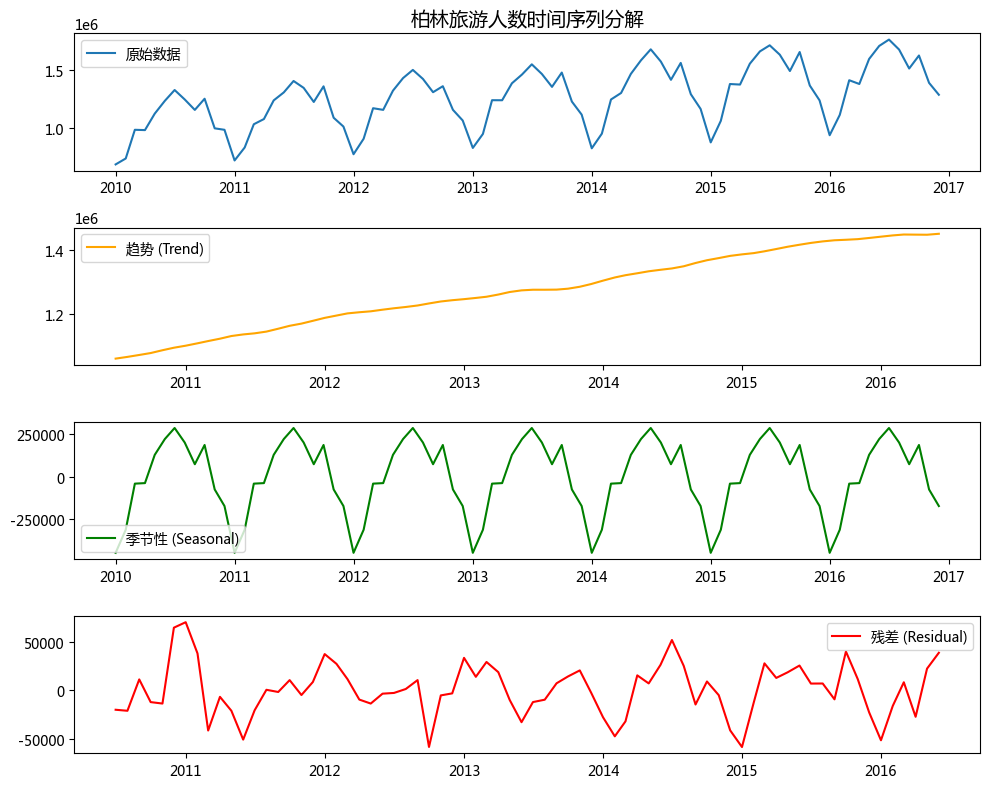

,成分,方差占比
0,趋势 (Trend),20.08%
1,季节性 (Seasonal),69.85%
2,残差 (Residual),1.05%


In [13]:

# 柏林旅游人数时间序列分解示例

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ======================
# 柏林旅游人数明细数据（2010-01 至 2016-12）
# ======================
data = {
    "date": ["2010-01-01","2010-02-01","2010-03-01","2010-04-01","2010-05-01","2010-06-01","2010-07-01","2010-08-01","2010-09-01","2010-10-01","2010-11-01","2010-12-01","2011-01-01","2011-02-01","2011-03-01","2011-04-01","2011-05-01","2011-06-01","2011-07-01","2011-08-01","2011-09-01","2011-10-01","2011-11-01","2011-12-01","2012-01-01","2012-02-01","2012-03-01","2012-04-01","2012-05-01","2012-06-01","2012-07-01","2012-08-01","2012-09-01","2012-10-01","2012-11-01","2012-12-01","2013-01-01","2013-02-01","2013-03-01","2013-04-01","2013-05-01","2013-06-01","2013-07-01","2013-08-01","2013-09-01","2013-10-01","2013-11-01","2013-12-01","2014-01-01","2014-02-01","2014-03-01","2014-04-01","2014-05-01","2014-06-01","2014-07-01","2014-08-01","2014-09-01","2014-10-01","2014-11-01","2014-12-01","2015-01-01","2015-02-01","2015-03-01","2015-04-01","2015-05-01","2015-06-01","2015-07-01","2015-08-01","2015-09-01","2015-10-01","2015-11-01","2015-12-01","2016-01-01","2016-02-01","2016-03-01","2016-04-01","2016-05-01","2016-06-01","2016-07-01","2016-08-01","2016-09-01","2016-10-01","2016-11-01","2016-12-01"],
    "Guests": [685205,736412,984546,981915,1124271,1234848,1328483,1246764,1156435,1253052,997147,984422,719384,831512,1032481,1077418,1238673,1307762,1406535,1346873,1225173,1360246,1088644,1012481,773264,907102,1171047,1156842,1322901,1431687,1502251,1424218,1309564,1361341,1157073,1064897,827619,948640,1240397,1239943,1386574,1462573,1550533,1466882,1355648,1479377,1228433,1115795,824401,951372,1246573,1302816,1467954,1585249,1680246,1574438,1416712,1562721,1292234,1164891,875573,1061875,1380289,1375598,1555673,1662431,1715018,1633745,1492662,1657031,1367584,1238945,937530,1113254,1413072,1380523,1596734,1709560,1764569,1678342,1514257,1626873,1390283,1287425]
}

# 创建 DataFrame
berlin_df = pd.DataFrame(data)
berlin_df["date"] = pd.to_datetime(berlin_df["date"])
berlin_df.set_index("date", inplace=True)
berlin_df = berlin_df.asfreq("MS")

# ======================
# 时间序列分解
# ======================
decomposition = seasonal_decompose(berlin_df["Guests"], model="additive")

# ======================
# 绘制中文分解图
# ======================

fig = plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(berlin_df.index, berlin_df["Guests"], label="原始数据")
plt.title("柏林旅游人数时间序列分解", fontsize=14)
plt.legend()

plt.subplot(412)
plt.plot(decomposition.trend, label="趋势 (Trend)", color="orange")
plt.legend()

plt.subplot(413)
plt.plot(decomposition.seasonal, label="季节性 (Seasonal)", color="green")
plt.legend()

plt.subplot(414)
plt.plot(decomposition.resid, label="残差 (Residual)", color="red")
plt.legend()

plt.tight_layout()
plt.show()

# ======================
# 各组成部分方差占比
# ======================
trend_var = decomposition.trend.var(skipna=True)
seasonal_var = decomposition.seasonal.var(skipna=True)
resid_var = decomposition.resid.var(skipna=True)
total_var = berlin_df["Guests"].var()

ratios = {
    "趋势 (Trend)": trend_var / total_var,
    "季节性 (Seasonal)": seasonal_var / total_var,
    "残差 (Residual)": resid_var / total_var
}

df = pd.DataFrame(ratios.items(), columns=["成分", "方差占比"])
df["方差占比"] = df["方差占比"].apply(lambda x: f"{x:.2%}")  # 转换为百分比格式
display(df)


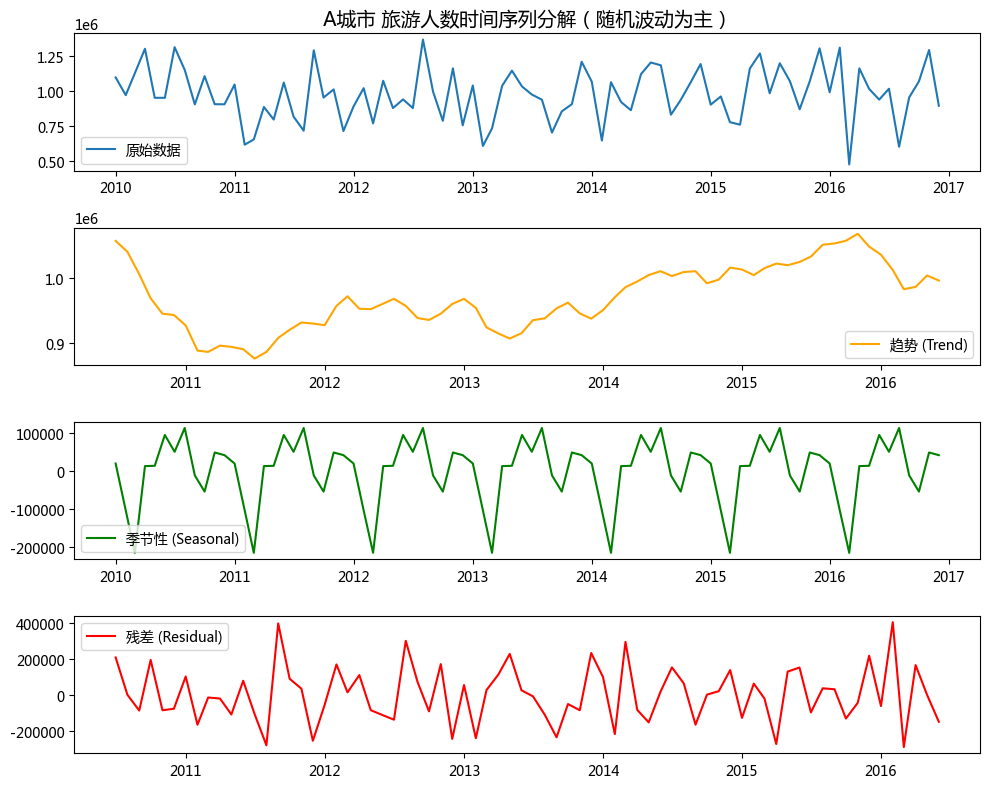

,成分,方差占比
0,趋势 (Trend),6.65%
1,季节性 (Seasonal),20.80%
2,残差 (Residual),69.25%


In [14]:
# A城市旅游人数时间序列分解示例（随机波动为主）

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ======================
# 模拟数据：随机波动为主，无明显趋势和季节性
# ======================
np.random.seed(42)
dates = pd.date_range(start="2010-01-01", periods=84, freq="MS")
guests = 1_000_000 + np.random.normal(0, 200_000, size=84).astype(int)

cityA_df = pd.DataFrame({"date": dates, "Guests": guests})
cityA_df.set_index("date", inplace=True)
cityA_df = cityA_df.asfreq("MS")

# ======================
# 时间序列分解
# ======================
decomposition = seasonal_decompose(cityA_df["Guests"], model="additive")

# ======================
# 绘制中文分解图
# ======================

fig = plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(cityA_df.index, cityA_df["Guests"], label="原始数据")
plt.title("A城市 旅游人数时间序列分解（随机波动为主）", fontsize=14)
plt.legend()

plt.subplot(412)
plt.plot(decomposition.trend, label="趋势 (Trend)", color="orange")
plt.legend()

plt.subplot(413)
plt.plot(decomposition.seasonal, label="季节性 (Seasonal)", color="green")
plt.legend()

plt.subplot(414)
plt.plot(decomposition.resid, label="残差 (Residual)", color="red")
plt.legend()

plt.tight_layout()
plt.show()

# ======================
# 各组成部分方差占比
# ======================
trend_var = decomposition.trend.var(skipna=True)
seasonal_var = decomposition.seasonal.var(skipna=True)
resid_var = decomposition.resid.var(skipna=True)
total_var = cityA_df["Guests"].var()

ratios = {
    "趋势 (Trend)": trend_var / total_var,
    "季节性 (Seasonal)": seasonal_var / total_var,
    "残差 (Residual)": resid_var / total_var
}

df = pd.DataFrame(ratios.items(), columns=["成分", "方差占比"])
df["方差占比"] = df["方差占比"].apply(lambda x: f"{x:.2%}")  # 转换为百分比格式
display(df)

## SARIMA 算法介绍 P39

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===============================
# 读取与准备数据
# ===============================

df = pd.read_csv("./data/air-passengers.csv")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

# 转换日期列并设为索引
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)

# 分割训练集和测试集
train = df.iloc[:-12]
test = df.iloc[-12:]

# 建立 SARIMA 模型
model = SARIMAX(train["Passengers"], order=(2, 1, 1), seasonal_order=(1, 1, 2, 12))
result = model.fit(disp=False)

# 预测测试集
forecast = result.forecast(steps=12)

# 计算 MAPE
mape = mean_absolute_percentage_error(test["Passengers"], forecast) * 100

print(f"MAPE: {mape:.2f}%")



/Users/jiyang/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/jiyang/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAPE: 2.85%


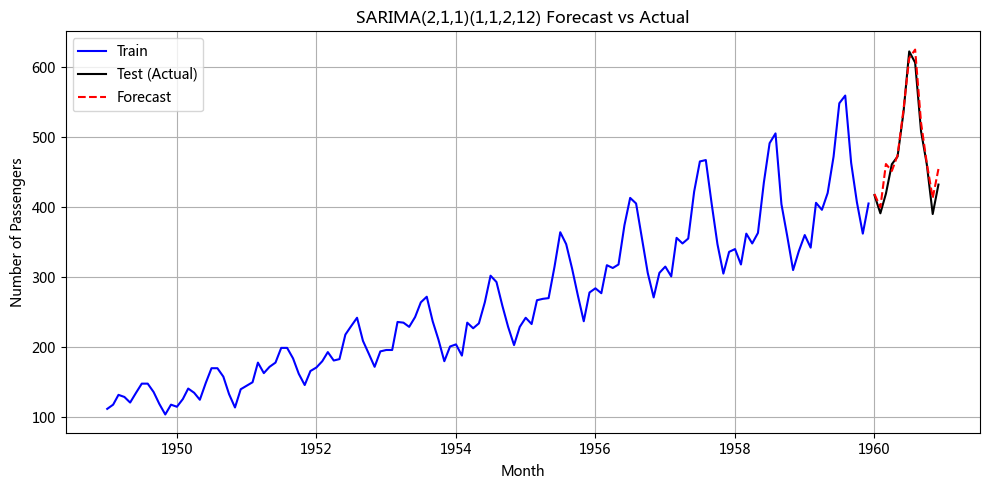

In [16]:
import matplotlib.pyplot as plt

# 绘制实际值与预测值对比折线图
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["Passengers"], label="Train", color="blue")
plt.plot(test.index, test["Passengers"], label="Test (Actual)", color="black")
plt.plot(test.index, forecast, label="Forecast", color="red", linestyle="--")
plt.title("SARIMA(2,1,1)(1,1,2,12) Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## auto_arima 自动化调参 P40

In [17]:
import pandas as pd
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error

# 读取数据
df = pd.read_csv("./data/air-passengers.csv")
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)

# 分割训练与测试集
train = df.iloc[:-12]
test = df.iloc[-12:]

# 自动 SARIMA 参数选择
model = pm.auto_arima(
    train['Passengers'],
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    trace=False
)

# 输出模型摘要
print(model.summary())

# 预测未来12个月
future_forecast = model.predict(n_periods=12)

# 计算 MAPE
mape = mean_absolute_percentage_error(test['Passengers'], future_forecast) * 100
print(f"MAPE: {mape:.2f}%")


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(3, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -447.843
Date:                            Wed, 05 Nov 2025   AIC                            905.686
Time:                                    16:26:36   BIC                            919.623
Sample:                                01-01-1949   HQIC                           911.346
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.5341      2.007      2.757      0.006       1.600       9.468
ar.L1          0.7049      0.095   

## Prophet 算法简介与应用 P42

16:26:36 - cmdstanpy - INFO - Chain [1] start processing
16:26:36 - cmdstanpy - INFO - Chain [1] done processing


MAPE: 0.0662


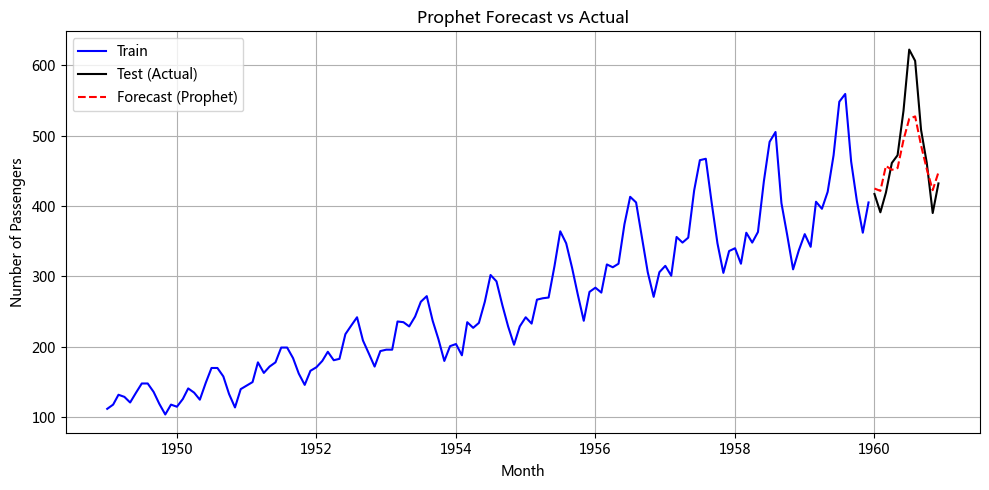

In [18]:
import logging

# 屏蔽 Prophet 和 CmdStanPy 的信息输出
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)


import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

df = pd.read_csv("./data/air-passengers.csv")
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])

# 划分训练集（除最后12个月）和测试集（最后12个月）
train = df.iloc[:-12]
test = df.iloc[-12:]

# 建模并拟合
model = Prophet()
model.fit(train)

# 生成未来日期, 预测未来12个月）
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# 提取预测结果（最后12个月对应 test）
pred = forecast[['ds', 'yhat']].iloc[-12:]

# 计算 MAPE
mape = mean_absolute_percentage_error(test['y'].values, pred['yhat'].values)
print(f"MAPE: {mape:.4f}")

# ===============================
# 绘图：实际 vs 预测
# ===============================
plt.figure(figsize=(10, 5))
plt.plot(train['ds'], train['y'], label="Train", color="blue")
plt.plot(test['ds'], test['y'], label="Test (Actual)", color="black")
plt.plot(pred['ds'], pred['yhat'], label="Forecast (Prophet)", color="red", linestyle="--")

plt.title("Prophet Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Prophet 算法简介与应用(调整参数) P44

MAPE: 0.0446


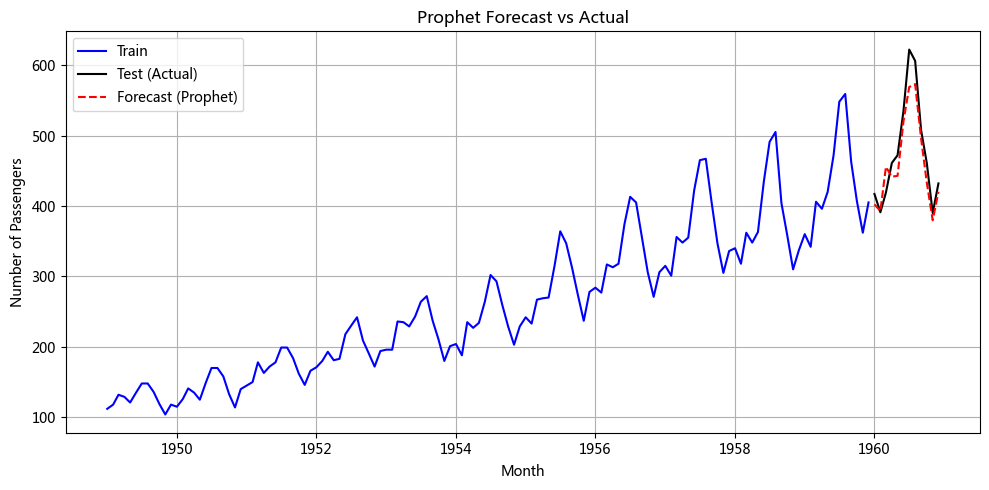

In [19]:
import logging

# 屏蔽 Prophet 和 CmdStanPy 的信息输出
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)


import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

df = pd.read_csv("./data/air-passengers.csv")
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])

# 划分训练集（除最后12个月）和测试集（最后12个月）
train = df.iloc[:-12]
test = df.iloc[-12:]

# 建模并拟合
model = Prophet(seasonality_mode='multiplicative')
model.fit(train)

# 生成未来日期, 预测未来12个月）
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# 提取预测结果（最后12个月对应 test）
pred = forecast[['ds', 'yhat']].iloc[-12:]

# 计算 MAPE
mape = mean_absolute_percentage_error(test['y'].values, pred['yhat'].values)
print(f"MAPE: {mape:.4f}")

# ===============================
# 绘图：实际 vs 预测
# ===============================
plt.figure(figsize=(10, 5))
plt.plot(train['ds'], train['y'], label="Train", color="blue")
plt.plot(test['ds'], test['y'], label="Test (Actual)", color="black")
plt.plot(pred['ds'], pred['yhat'], label="Forecast (Prophet)", color="red", linestyle="--")

plt.title("Prophet Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Prophet 节假日配置

In [20]:
import pandas as pd

# 定义节假日
holidays_df = pd.DataFrame({
  'holiday': '新年',
  'ds': pd.to_datetime(['2023-01-01', '2024-01-01', '2025-01-01']),
  'lower_window': 0,   # 节日前的天数
  'upper_window': 1    # 节日后的天数
})

mode = Prophet(holidays=holidays_df)

In [21]:
import pandas as pd

holidays_df = pd.DataFrame({
    'holiday': [
        '元旦', '元旦', '元旦',
        '中秋', '中秋', '中秋'
    ],
    'ds': pd.to_datetime([
        '2023-01-01', '2024-01-01', '2025-01-01',  # 元旦
        '2023-09-29', '2024-09-17', '2025-10-06'   # 中秋
    ]),
    'lower_window': [0, 0, 0, -3, -3, -3],  # 节日前的天数
    'upper_window': [1, 1, 1, 1, 1, 1]   # 节日后的天数
})


mode = Prophet(holidays=holidays_df)

# 聚类

## 层次聚类 P55

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

file_path = "./data/供应商数据.csv"
df = pd.read_csv(file_path)

# 要使用的列
cols = ["price_index", "defect_rate_pct"]

# 标准化
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[cols])

# 层次聚类
Z = linkage(data_scaled, method="ward")

# 不同的 K 值剪枝
clusters_k3 = fcluster(Z, 3, criterion="maxclust")
clusters_k4 = fcluster(Z, 4, criterion="maxclust")

# 合并结果
data_with_clusters = df[cols].copy()
data_with_clusters["cluster_k3"] = clusters_k3
data_with_clusters["cluster_k4"] = clusters_k4

# 输出结果
display(data_with_clusters.head(100))

# 计算轮廓系数
score_k3 = silhouette_score(data_scaled, clusters_k3)
score_k4 = silhouette_score(data_scaled, clusters_k4)

print(f"3 类聚类的轮廓系数: {score_k3:.3f}")
print(f"4 类聚类的轮廓系数: {score_k4:.3f}")


,price_index,defect_rate_pct,cluster_k3,cluster_k4
0,1.012,0.46,1,2
1,1.089,0.48,1,2
2,1.056,0.53,1,2
3,1.043,0.32,1,2
4,1.034,0.37,1,2
...,...,...,...,...
95,0.879,1.25,2,3
96,0.838,1.04,2,3
97,0.799,1.12,2,3
98,0.889,1.14,2,3


3 类聚类的轮廓系数: 0.636
4 类聚类的轮廓系数: 0.561


## 层次聚类树状图 P56

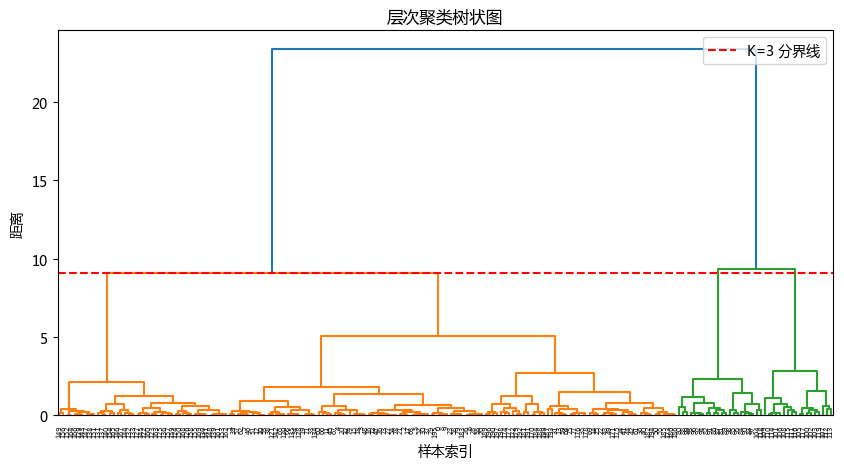

In [23]:
import matplotlib.pyplot as plt
import matplotlib
from scipy.cluster.hierarchy import dendrogram

# 绘制树状图
plt.figure(figsize=(10, 5))
plt.title("层次聚类树状图")
plt.xlabel("样本索引")
plt.ylabel("距离")

# 使用上一段代码的聚类结果：Z
dendrogram(Z) 

plt.axhline(y=Z[-3, 2], color='red', linestyle='--', label='K=3 分界线')
plt.legend()
plt.show()

## 聚类的均值特征 P58

In [24]:
# 选择用于聚类的字段
cols = [
    "price_index", "quality_score", "on_time_rate", "lead_time_days",
    "defect_rate_pct", "distance_km", "capacity_score", "annual_spend_million",
    "orders_per_year", "min_moq", "contract_years", "risk_score"
]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[cols])

# 计算层次聚类
Z = linkage(data_scaled, method="ward")

# 生成不同 K 值的聚类标签
df["cluster_k2"] = fcluster(Z, 2, criterion="maxclust")
df["cluster_k3"] = fcluster(Z, 3, criterion="maxclust")

display(df.groupby("cluster_k2")[cols].mean().reset_index())



,cluster_k2,price_index,quality_score,on_time_rate,lead_time_days,defect_rate_pct,distance_km,capacity_score,annual_spend_million,orders_per_year,min_moq,contract_years,risk_score
0,1,0.798650,75.42500,83.61750,8.90000,1.438750,132.07500,40.175,0.730225,37.60000,71.75000,0.70000,48.2000
1,2,1.076725,90.93125,92.71375,15.54375,0.479563,1582.26875,76.825,3.169713,37.68125,1175.89375,5.13125,24.6375


## 保存聚类的结果 P59

In [25]:
# 定义命名映射
k2_name_map = {1: "基础供应商", 2: "优质供应商"}
k3_name_map = {1: "基础供应商", 2: "战略合作伙伴", 3: "高端远程供应商"}

# 添加命名列
df["cluster_k2_name"] = df["cluster_k2"].map(k2_name_map)
df["cluster_k3_name"] = df["cluster_k3"].map(k3_name_map)

# 重新排列列顺序：把聚类相关列放前面
new_order = [ "supplier_id",
    "cluster_k2", "cluster_k2_name",
    "cluster_k3", "cluster_k3_name"
] + cols  # 再接上原始指标列

df = df[new_order]

# 查看前几行
display(df.head(10))

# UTF-8 with BOM to ensure Excel compatibility
df.to_csv("./data/供应商 - 聚类结果.csv", index=False, encoding='utf-8-sig')

,supplier_id,cluster_k2,cluster_k2_name,cluster_k3,cluster_k3_name,price_index,quality_score,on_time_rate,lead_time_days,defect_rate_pct,distance_km,capacity_score,annual_spend_million,orders_per_year,min_moq,contract_years,risk_score
0,S001,2,优质供应商,2,战略合作伙伴,1.012,93,92.8,6,0.46,81,68,1.771,27,117,6,16
1,S002,2,优质供应商,2,战略合作伙伴,1.089,89,97.0,9,0.48,59,69,1.956,28,111,8,14
2,S003,2,优质供应商,2,战略合作伙伴,1.056,86,93.5,7,0.53,70,64,1.899,44,131,5,25
3,S004,2,优质供应商,2,战略合作伙伴,1.043,95,93.7,7,0.32,47,77,2.571,46,72,5,19
4,S005,2,优质供应商,2,战略合作伙伴,1.034,94,95.2,8,0.37,85,75,1.672,40,129,6,15
5,S006,2,优质供应商,2,战略合作伙伴,1.049,92,93.3,6,0.50,79,72,2.248,55,151,8,23
6,S007,2,优质供应商,2,战略合作伙伴,1.048,93,95.5,6,0.37,57,71,1.759,43,147,9,24
7,S008,2,优质供应商,2,战略合作伙伴,1.080,92,93.3,9,0.43,66,68,0.722,37,96,5,22
8,S009,2,优质供应商,2,战略合作伙伴,1.027,88,95.2,8,0.44,125,68,1.160,55,148,4,22
9,S010,2,优质供应商,2,战略合作伙伴,1.020,91,93.3,7,0.44,62,70,1.164,57,149,5,15


## 新的供应商数据如何应用层次聚类

In [26]:
import numpy as np

# 新供应商数据（举例）
new_supplier = {
    "price_index": 1.08,
    "quality_score": 92,
    "on_time_rate": 94,
    "lead_time_days": 7,
    "defect_rate_pct": 0.42,
    "distance_km": 120,
    "capacity_score": 72,
    "annual_spend_million": 2.3,
    "orders_per_year": 45,
    "min_moq": 150,
    "contract_years": 6,
    "risk_score": 20
}

# 转换为 DataFrame
new_df = pd.DataFrame([new_supplier])

# 用原来的 scaler 进行标准化
new_scaled = scaler.transform(new_df[cols])

# 计算它与各簇中心的距离（以 K=3 为例）
centroids = df.groupby("cluster_k3")[cols].mean()
centroids_scaled = scaler.transform(centroids)  # 同样标准化中心

distances = np.linalg.norm(new_scaled - centroids_scaled, axis=1)
assigned_cluster = np.argmin(distances) + 1  # 找最近簇

print(f"该供应商属于 cluster_k3  的第 {assigned_cluster} 个簇")

该供应商属于 cluster_k3  的第 2 个簇


# 特征工程（下）

## 特征选择的方法 - 卡方检验 P65

In [27]:
import numpy as np
from scipy.stats import chi2_contingency

# 新的数据：接近独立，但各区域比例略有不同
data_almost = np.array([[67, 33], 
                        [71, 29], 
                        [70, 30]])

# 卡方检验
_, p_almost, _, _ = chi2_contingency(data_almost)


print(f" p = {p_almost:.4f}")

 p = 0.8156


## 嵌入法（Embedded）P70

In [28]:
# =============================
# 特征选择示例：基于决策树的重要性排序
# 任务：预测订单是否准时交付
# =============================

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. 构造模拟供应链数据集
np.random.seed(42)
n_samples = 200

data = pd.DataFrame({
    "供应商等级": np.random.choice([1, 2, 3], size=n_samples, p=[0.3, 0.5, 0.2]),  # 供应商等级
    "节假日": np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3]),             # 是否节假日
    "天气": np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2]),               # 是否恶劣天气
    "仓库编码": np.random.choice([101, 102, 103], size=n_samples),                # 仓库编码
})

# 2. 生成目标变量（是否准时交付：1=准时, 0=延迟）
data["准时交付"] = (
    (data["供应商等级"] == 3).astype(int) * 0.5
    + (1 - data["节假日"]) * 0.3
    + (1 - data["天气"]) * 0.15
    + np.random.rand(n_samples) * 0.2
)
data["准时交付"] = (data["准时交付"] > 0.5).astype(int)

print("示例数据预览：")
print(data.head())

# 3. One-hot 编码类别型特征（仓库编码）
X = pd.get_dummies(data.drop("准时交付", axis=1), drop_first=True)
y = data["准时交付"]

# 4. 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. 训练决策树模型
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 6. 输出特征重要性（保留3位小数）
dt_importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
dt_importances = dt_importances.round(3)

# 7. 模型准确率
dt_acc = accuracy_score(y_test, dt.predict(X_test))

print("\n🎯 决策树特征重要性：")
print(dt_importances)

print(f"\n模型准确率：{dt_acc:.3f}")


示例数据预览：
   供应商等级  节假日  天气  仓库编码  准时交付
0      2    0   0   101     0
1      3    0   1   102     1
2      2    0   0   102     0
3      2    1   1   101     0
4      1    0   0   102     1

🎯 决策树特征重要性：
供应商等级    0.380
天气       0.296
节假日      0.294
仓库编码     0.031
dtype: float64

模型准确率：0.867


## 使用PCA方法进行降维 P73

In [29]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df_data = pd.read_csv("./data/data_pca_demo.csv")

X = df_data[["节假日","促销强度","天气温度","降雨量","季节编码","特殊节假日","大型促销活动","库存水平"]]
y = df_data["销量"]

# 划分训练集（<=9月16日）和测试集（>9月16日）
train_mask = df_data["日期"] <= "2025-09-16"
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# 线性回归
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE(不用PCA):", round(mean_squared_error(y_test, y_pred), 2))

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = df_data[["节假日","促销强度","天气温度","降雨量","季节编码","特殊节假日","大型促销活动","库存水平"]]
y = df_data["销量"]

# 标准化 + PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 划分训练集和测试集
train_mask = df_data["日期"] <= "2025-09-16"
X_train, X_test = X_pca[train_mask], X_pca[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]
# 线性回归
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MSE(用PCA):", round(mean_squared_error(y_test, y_pred), 2))

MSE(不用PCA): 834.34
MSE(用PCA): 1264.25


## 使用PCA方法进行降维(输出载荷矩阵) P74

In [30]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 特征矩阵
X = df_data[["节假日","促销强度","天气温度","降雨量","季节编码","特殊节假日","大型促销活动","库存水平"]]

# 标准化 + PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=3)
pca.fit(X_scaled)

# 输出载荷矩阵
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

display(loadings.round(4))

,PC1,PC2,PC3
节假日,0.2683,-0.5538,-0.4521
促销强度,0.6130,-0.1361,-0.1222
天气温度,0.2089,0.3359,-0.5220
降雨量,-0.5411,0.1499,-0.2588
季节编码,0.0000,0.0000,-0.0000
特殊节假日,0.2482,-0.1494,0.5264
大型促销活动,0.3032,0.6097,-0.1836
库存水平,0.2497,0.3813,0.3613


## 聚类 + PCA降维的可视化 P74

### 先降维再聚类

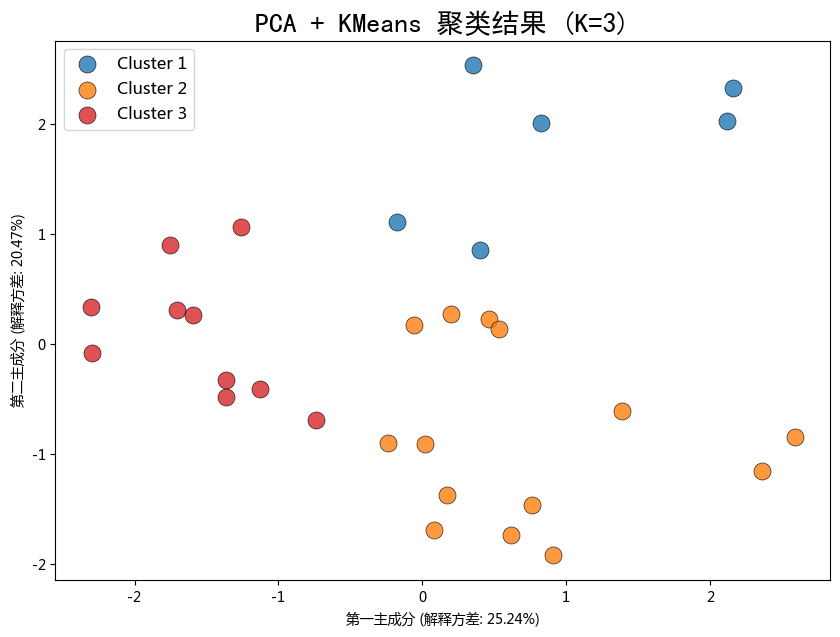

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 读取数据
df = pd.read_csv("./data/data_pca_demo.csv")

# 特征列
features = ["节假日","促销强度","天气温度","降雨量","季节编码","特殊节假日","大型促销活动","库存水平"]
X = df[features]

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 降维到 2 维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# KMeans 聚类 (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# 构造 DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters

# 定义三种颜色：蓝、橙、红
colors = ["#1f77b4", "#ff7f0e", "#d62728"]

# 绘制散点图（点大 + 更醒目标题）
plt.figure(figsize=(10, 7))
for i in range(3):
    subset = pca_df[pca_df["Cluster"] == i]
    plt.scatter(subset["PC1"], subset["PC2"],
                label=f"Cluster {i+1}",
                color=colors[i],
                s=150,
                alpha=0.8,
                edgecolor="k",
                linewidths=0.5)

# 美化
plt.xlabel(f"第一主成分 (解释方差: {pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"第二主成分 (解释方差: {pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA + KMeans 聚类结果 (K=3)", fontproperties="SimHei", fontsize=20)  # ← 标题更大
plt.legend(fontsize=12)
plt.grid(False)
plt.show()


### 先聚类再降维


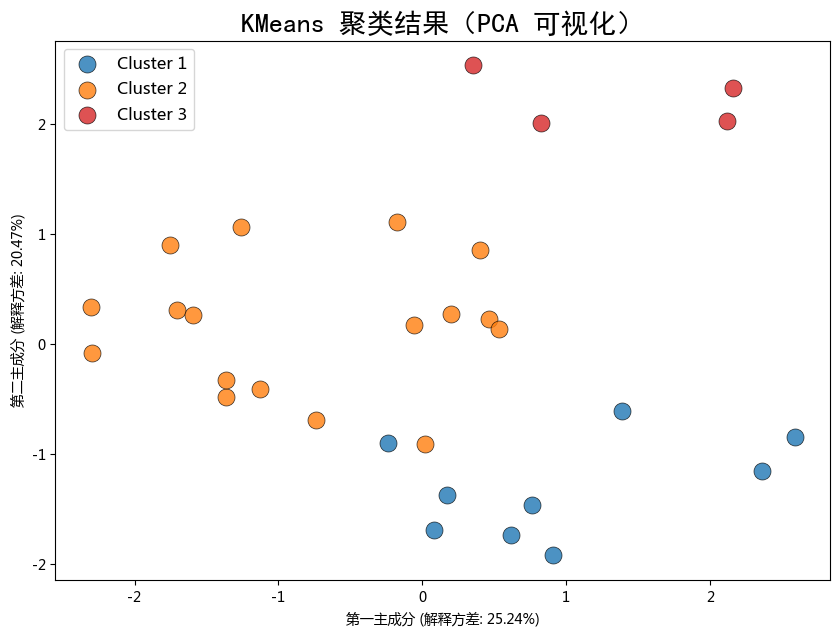

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 读取数据
df = pd.read_csv("./data/data_pca_demo.csv")

# 特征列
features = ["节假日","促销强度","天气温度","降雨量","季节编码","特殊节假日","大型促销活动","库存水平"]
X = df[features]

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ① KMeans 聚类 (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# ② PCA 降维（仅用于画图展示）
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 构造 DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters

# 绘制散点图
colors = ["#1f77b4", "#ff7f0e", "#d62728"]
plt.figure(figsize=(10, 7))
for i in range(3):
    subset = pca_df[pca_df["Cluster"] == i]
    plt.scatter(subset["PC1"], subset["PC2"],
                label=f"Cluster {i+1}",
                color=colors[i],
                s=150,
                alpha=0.8,
                edgecolor="k",
                linewidths=0.5)

plt.xlabel(f"第一主成分 (解释方差: {pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"第二主成分 (解释方差: {pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("KMeans 聚类结果（PCA 可视化）", fontproperties="SimHei", fontsize=20)
plt.legend(fontsize=12)
plt.grid(False)
plt.show()


# XGBoost

## XGBoost 代码调用 （分类）P82

In [33]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = pd.read_csv("./data/titanic/train.csv")

# 选择特征列
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = data[features]
y = data['Survived']

# 对 Sex 和 Embarked 进行独热编码
X = pd.get_dummies(X, columns=['Sex', 'Embarked'])

# 划分训练集和测试集（8:2）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 创建并训练 XGBoost 模型（常用参数）
model = XGBClassifier(
    n_estimators=200,                    # 树的数量
    learning_rate=0.05,                  # 学习率
    max_depth=5,                            # 树的最大深度
    objective='binary:logistic',    # 二分类任务
    eval_metric='logloss',             # 二分类常用评估指标
    use_label_encoder=False,     # 禁用旧版标签编码器
    random_state=42                      # 随机种子
)

# 模型训练
model.fit(X_train, y_train)

# 在测试集上预测
y_pred = model.predict(X_test)

# 输出准确率
acc = accuracy_score(y_test, y_pred)
print(f"测试集准确率: {acc:.4f}")

测试集准确率: 0.8045


## XGBoost 代码调用 （回归）P83

In [34]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = pd.read_csv("./data/titanic/train.csv")

data = data.dropna(subset=['Age'])

features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = data[features]
y = data['Age']   #  目标变量：年龄（连续值）

# 对 Sex 和 Embarked 进行独热编码
X = pd.get_dummies(X, columns=['Sex', 'Embarked'])

# 划分训练集和测试集（8:2）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建并训练 XGBoost 回归模型
model = XGBRegressor(
    n_estimators=200,                            # 树的数量
    learning_rate=0.05,                           # 学习率
    max_depth=5,                                     # 树的最大深度
    objective='reg:squarederror',   # 回归任务目标函数
    eval_metric='rmse',                        # 回归常用评估指标
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"测试集 RMSE: {rmse:.4f}")
print(f"测试集 MAE:  {mae:.4f}")
print(f"测试集 R²:   {r2:.4f}")


测试集 RMSE: 11.1046
测试集 MAE:  8.9869
测试集 R²:   0.3349


## 内置特征重要性分析

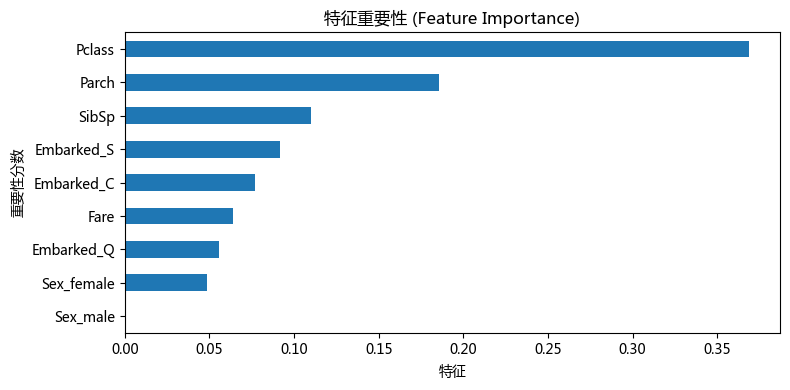

In [35]:
# 计算特征重要性并排序
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

# 画条形图
feature_importance.plot(kind='barh', figsize=(8, 4))
plt.title("特征重要性 (Feature Importance)")
plt.ylabel("重要性分数")
plt.xlabel("特征")
plt.tight_layout()
plt.show()

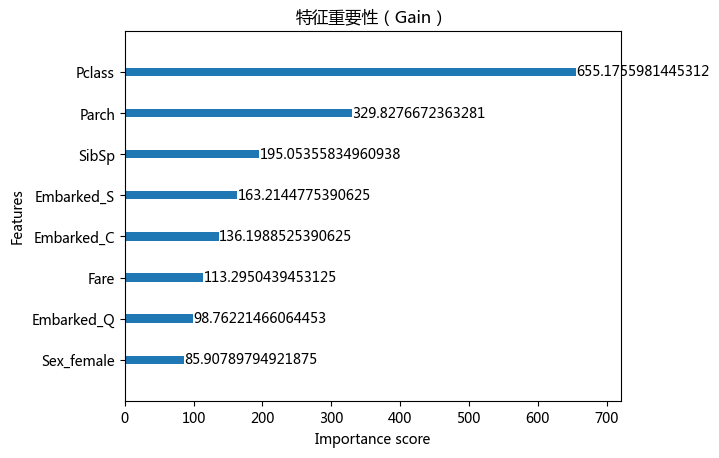

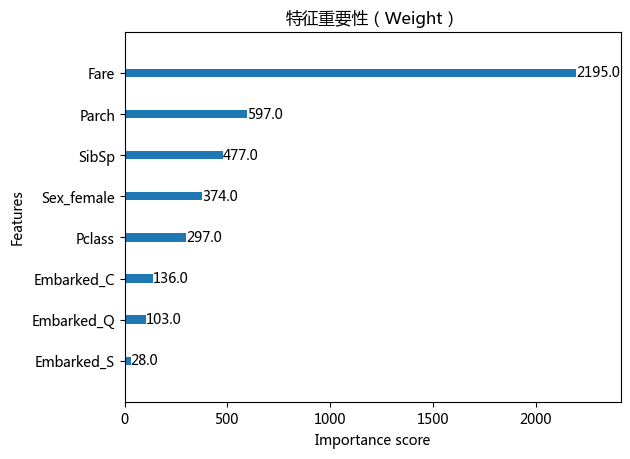

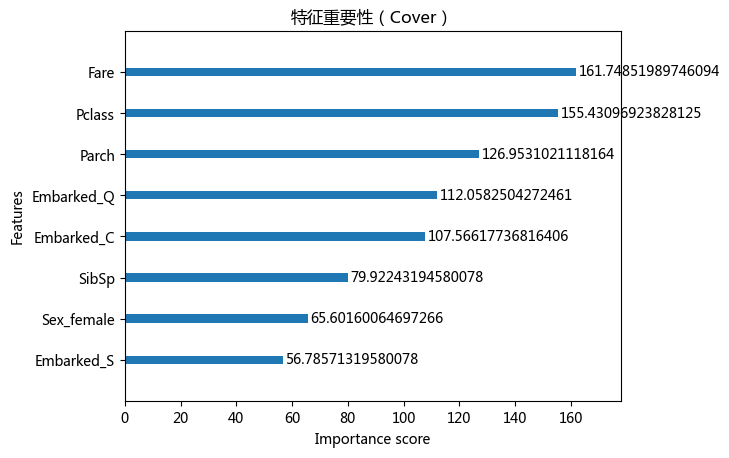

In [36]:
from xgboost import XGBClassifier, plot_importance
import matplotlib.pyplot as plt

plot_importance(model, importance_type='gain')
plt.title("特征重要性（Gain）")
plt.grid(False)
plt.show()

plot_importance(model, importance_type='weight')
plt.title("特征重要性（Weight）")
plt.grid(False)
plt.show()

plot_importance(model, importance_type='cover')
plt.title("特征重要性（Cover）")
plt.grid(False)
plt.show()


## 支持类别型特征 P85

In [37]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 读取数据
data = pd.read_csv("./data/titanic/train.csv")

# 删除 Age 缺失值
data = data.dropna(subset=['Age'])

# 将分类变量转为 category 类型
data['Sex'] = data['Sex'].astype('category')
data['Embarked'] = data['Embarked'].astype('category')

# 特征与目标
features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = data[features]
y = data['Age']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建并训练 XGBoost 回归模型（支持类别型特征）
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    objective='reg:squarederror',
    eval_metric='rmse',
    enable_categorical=True,  # 关键：启用类别特征支持
    random_state=42
)

model.fit(X_train, y_train)

# 预测
y_pred = model.predict(X_test)

# 评估指标
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"测试集 RMSE: {rmse:.4f}")
print(f"测试集 MAE:  {mae:.4f}")
print(f"测试集 R²:   {r2:.4f}")

# from xgboost import XGBClassifier, plot_importance
# import matplotlib.pyplot as plt

# plot_importance(model, importance_type='gain')
# plt.title("特征重要性（Gain）")
# plt.grid(False)
# plt.show()


测试集 RMSE: 11.1801
测试集 MAE:  9.0980
测试集 R²:   0.3258


## 支持自动早停 P86

In [38]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 读取数据
data = pd.read_csv("./data/titanic/train.csv")

# 删除 Age 缺失值
data = data.dropna(subset=['Age'])

# 将分类变量转为 category 类型
data['Sex'] = data['Sex'].astype('category')
data['Embarked'] = data['Embarked'].astype('category')

# 特征与目标
features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = data[features]
y = data['Age']

# 先划分训练+测试，再从训练中划出验证集
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# 创建并训练 XGBoost 回归模型（支持类别型特征 + 早停）
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    objective='reg:squarederror',
    eval_metric='rmse',
    enable_categorical=True,
    early_stopping_rounds=10,   # 连续10轮无提升则停止
    random_state=42
)

# 训练模型并使用验证集进行早停
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# 最佳迭代次数
print(f"最佳迭代轮次: {model.best_iteration}")

# 使用最佳模型预测
y_pred = model.predict(X_test)

# 评估指标
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# print(f"测试集 RMSE: {rmse:.4f}")
# print(f"测试集 MAE:  {mae:.4f}")
# print(f"测试集 R²:   {r2:.4f}")


最佳迭代轮次: 25


# 供应链场景的出货量预测

## 安装 xgboost

In [39]:
# 安装 xgboost
!pip install xgboost

## 时间序列 SARIMAX P93

In [40]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ========== 读取数据 ==========
df = pd.read_csv("./data/出货量预测/SalesShip.csv")
df["yearMonth"] = pd.to_datetime(df["yearMonth"], format="%Y-%m")


# ========== 按 Region, ItemCode 分别预测下一个月 ==========
forecast_results = []

for (region, item), group in df.groupby(["Region", "ItemCode"]):
    series = group.groupby("yearMonth")["ShipQty"].sum().sort_index()

    # 至少保证 24 个点
    if len(series) < 24:
        continue

    # 训练集为除最后一个月外所有数据，最后一个月为预测目标
    train = series.iloc[:-1]
    test = series.iloc[-1:]

    if len(train) < 12:
        continue

    try:
        model = SARIMAX(
            train,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 12)
        )
        result = model.fit(disp=False)

        forecast = result.forecast(steps=1)
        y_true = test.values[0]
        y_pred = forecast.values[0]

        forecast_results.append({
            "Region": region,
            "ItemCode": item,
            "y_true": y_true,
            "y_pred": y_pred
        })

    except Exception as e:
        print(f"{region}-{item} 出错: {e}")

# ========== 汇总结果 ==========
pred_df = pd.DataFrame(forecast_results)
pred_df = pred_df[pred_df["y_true"] > 0]

# 计算总体 FA
fa_all = 1 - np.sum(np.abs(pred_df["y_pred"] - pred_df["y_true"])) / np.sum(pred_df["y_true"])

print("\n===== 整体 SARIMA 预测表现（按 Region + ItemCode） =====")
print(f"FA（预测准确率）: {fa_all:.4f}")

# ========== 按 Region 汇总 FA ==========
region_stats = []

for region, g in pred_df.groupby("Region"):
    y_true = g["y_true"].values
    y_pred = g["y_pred"].values
    fa = 1 - np.sum(np.abs(y_pred - y_true)) / np.sum(y_true)
    region_stats.append((region, fa))

fa_df = pd.DataFrame(region_stats, columns=["Region", "FA"]).sort_values("FA", ascending=False)

print("\n===== 各 Region SARIMA 预测表现 =====")
print(fa_df.to_string(index=False))


/Users/jiyang/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/jiyang/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/jiyang/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/jiyang/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/jiyang/miniforge3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fre


===== 整体 SARIMA 预测表现（按 Region + ItemCode） =====
FA（预测准确率）: 0.6539

===== 各 Region SARIMA 预测表现 =====
Region       FA
  West 0.797208
 North 0.726958
 South 0.630295
 Inner 0.593019
  East 0.544710


/Users/jiyang/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 时间序列 应用Auto_arima调参 P93

In [41]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima

# ========== 读取数据 ==========
df = pd.read_csv("./data/出货量预测/SalesShip.csv")
df["yearMonth"] = pd.to_datetime(df["yearMonth"], format="%Y-%m")

# ========== 按 Region, ItemCode 分别预测下一个月 ==========
forecast_results = []

for (region, item), group in df.groupby(["Region", "ItemCode"]):
    series = group.groupby("yearMonth")["ShipQty"].sum().sort_index()

    # 至少保证 24 个点
    if len(series) < 24:
        continue

    # 用前 n-1 个月训练，最后一个月预测
    train = series.iloc[:-1]
    test = series.iloc[-1:]

    if len(train) < 12:
        continue

    try:
        # 自动选择最佳 ARIMA 参数（含季节性）
        model = auto_arima(
            train,
            seasonal=True,
            m=12,                # 12个月为一个季节周期
            stepwise=True,       # 启用逐步搜索以提高效率
            suppress_warnings=True,
            error_action="ignore"
        )

        # 预测下一个月
        forecast = model.predict(n_periods=1)
        y_true = test.values[0]
        y_pred = forecast[0]

        forecast_results.append({
            "Region": region,
            "ItemCode": item,
            "y_true": y_true,
            "y_pred": y_pred
        })

    except Exception as e:
        print(f"{region}-{item} 出错: {e}")

# ========== 汇总结果 ==========
pred_df = pd.DataFrame(forecast_results)
pred_df = pred_df[pred_df["y_true"] > 0]

# 计算总体 FA
fa_all = 1 - np.sum(np.abs(pred_df["y_pred"] - pred_df["y_true"])) / np.sum(pred_df["y_true"])

print("\n===== 整体 Auto ARIMA 预测表现（按 Region + ItemCode） =====")
print(f"FA（预测准确率）: {fa_all:.4f}")

# ========== 按 Region 汇总 FA ==========
region_stats = []

for region, g in pred_df.groupby("Region"):
    y_true = g["y_true"].values
    y_pred = g["y_pred"].values
    fa = 1 - np.sum(np.abs(y_pred - y_true)) / np.sum(y_true)
    region_stats.append((region, fa))

fa_df = pd.DataFrame(region_stats, columns=["Region", "FA"]).sort_values("FA", ascending=False)

print("\n===== 各 Region Auto ARIMA 预测表现 =====")
print(fa_df.to_string(index=False))



===== 整体 Auto ARIMA 预测表现（按 Region + ItemCode） =====
FA（预测准确率）: 0.7101

===== 各 Region Auto ARIMA 预测表现 =====
Region       FA
 Inner 0.856370
  West 0.768561
 South 0.724614
 North 0.606693
  East 0.595162


## 应用随机森林进行预测 P95

In [42]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# ========== 读取数据 ==========
df = pd.read_csv('./data/出货量预测/SalesShip.csv')
df["yearMonth"] = pd.to_datetime(df["yearMonth"], format="%Y-%m")

# ========== 分类特征处理（使用One-Hot编码） ==========
cat_cols = ["Region", "ItemCode", "Package"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ========== 训练集 / 测试集划分 ==========
df = df.sort_values("yearMonth").reset_index(drop=True)
last_month = df["yearMonth"].max()
train_df = df[df["yearMonth"] < last_month]
test_df = df[df["yearMonth"] == last_month]

target_col = "ShipQty"
feature_cols = [
    "Month",
    "ShipQty(-1)", "ShipQty(-2)", "ShipQty(-3)", "ShipQty(-4)",
    "SalesQty(-1)", "SalesQty(-2)", "SalesQty(-3)",
    "ItemShare(-1)"
] + [c for c in df.columns if c.startswith(("Region_", "ItemCode_", "Package_"))]

X_train, y_train = train_df[feature_cols].copy(), train_df[target_col]
X_test, y_test = test_df[feature_cols].copy(), test_df[target_col]

# ========== 随机森林训练 ==========

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
pred = model.predict(X_test)

test_df = test_df.copy()
test_df["Pred_ShipQty"] = pred
test_df["Actual_ShipQty"] = y_test.values

# ========== 计算总体 FA ==========
mask = test_df["Actual_ShipQty"] > 0
if mask.sum() > 0:
    total_actual = test_df.loc[mask, "Actual_ShipQty"].sum()
    total_abs_error = np.sum(np.abs(test_df.loc[mask, "Pred_ShipQty"] - test_df.loc[mask, "Actual_ShipQty"]))
    total_FA = 1 - total_abs_error / total_actual
else:
    total_FA = np.nan

# ========== 输出结果 ==========
print("\n===== 总体预测准确度 (FA_total) =====")
print(f"FA_total: {total_FA:.4f}")



===== 总体预测准确度 (FA_total) =====
FA_total: 0.7931


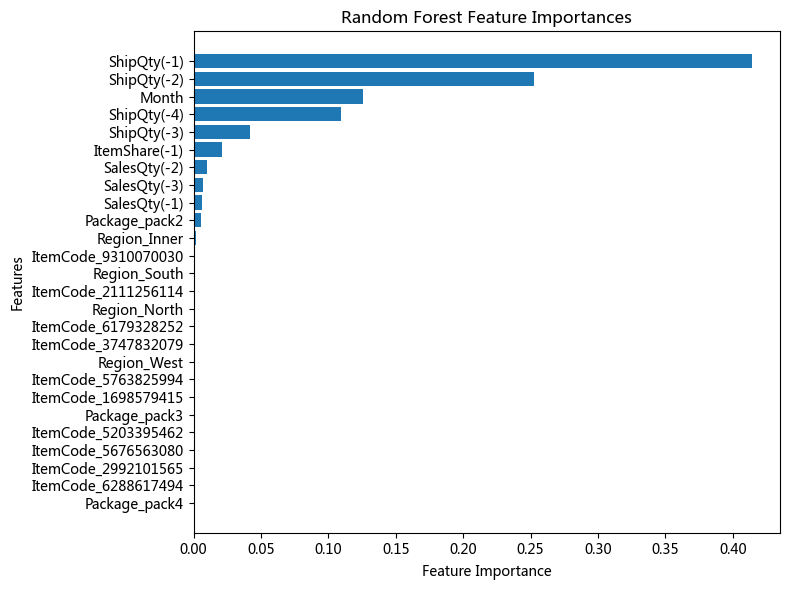

In [43]:
# ========== 特征重要性可视化 ==========

import numpy as np
import matplotlib.pyplot as plt

# ========== 特征重要性 ==========
importances = model.feature_importances_
feature_names = X_train.columns

# 按重要性排序
indices = np.argsort(importances)[::-1]
sorted_features = feature_names[indices]
sorted_importances = importances[indices]

# ========== 绘制条形图 ==========
plt.figure(figsize=(8, 6))
plt.barh(sorted_features, sorted_importances)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()  # 让最重要的特征在上方
plt.tight_layout()
plt.show()


## 应用 XGBoost 进行预测  P96

In [44]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ========== 1. 读取数据 ==========
df = pd.read_csv('./data/出货量预测/SalesShip.csv')
df["yearMonth"] = pd.to_datetime(df["yearMonth"], format="%Y-%m")
# # ========== 2. 排除低FA Region + ItemCode ==========
# exclude_pairs = [
#     ("Inner", 3331397693),
#     ("West", 6179328252),
#     ("Inner", 5763825994),
#     ("Inner", 6179328252),
#     ("West", 9310070030),
#     ("West", 2992101565),
#     ("South", 5676563080),
#     ("Inner", 9310070030),
#     ("East", 6179328252),
#     ("North", 5763825994),
#     ("Inner", 6288617494),
#     ("North", 5203395462),
# ]
# exclude_df = pd.DataFrame(exclude_pairs, columns=["Region", "ItemCode"])
# df = df.merge(exclude_df, on=["Region", "ItemCode"], how="left", indicator=True)
# df = df[df["_merge"] == "left_only"].drop(columns="_merge")
# ========== 2. 特征选择 ==========
exclude_cols = ["SalesQty", "ItemShare", "ShipQty"]

feature_cols = [c for c in df.columns if c not in exclude_cols + ["yearMonth"]]

# 不做 One-hot 编码，让 XGBoost 原生处理分类特征
cat_cols = ["Region", "ItemCode", "Package"]
for c in cat_cols:
    df[c] = df[c].astype("category")
    df[c] = df[c].cat.remove_unused_categories()

# 定义目标列与时间列
target_col = "ShipQty"
time_col = "yearMonth"

# ========== 3. 划分训练集和预测集 ==========
train_df = df[df[time_col] < "2017-11-01"]
test_df = df[df[time_col] >= "2017-11-01"]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

# ========== 4. 使用固定参数训练模型 ==========
best_params = {
    'max_depth': 5,
    'learning_rate': 0.02,
    'subsample': 0.9,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.5,
    'reg_lambda': 1,
    'n_estimators': 500
}

model = XGBRegressor(
    random_state=42,
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=100,
    **best_params
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# ========== 5. 预测 ==========
pred_best = model.predict(X_test)

# ========== 6. 计算评估指标 ==========
mae_best = mean_absolute_error(y_test, pred_best)
r2_best = r2_score(y_test, pred_best)

mask = y_test > 0
if np.any(mask):
    mape_best = np.mean(np.abs((y_test[mask] - pred_best[mask]) / y_test[mask])) * 100
    FA_best = 1 - np.sum(np.abs(pred_best[mask] - y_test[mask])) / np.sum(y_test[mask])
else:
    mape_best = np.nan
    FA_best = np.nan

print("\n===== 模型评估结果 =====")
print(f"MAE:  {mae_best:.2f}")
print(f"R²:   {r2_best:.4f}")
print(f"MAPE（仅 ShipQty > 0）: {mape_best:.2f}%")
print(f"FA（预测准确率）: {FA_best:.4f}")

# ========== 7. 输出预测结果 ==========
pred_result = test_df.copy().reset_index(drop=True)
pred_result["Pred_ShipQty"] = pred_best
pred_result["Actual_ShipQty"] = y_test.values



===== 模型评估结果 =====
MAE:  707.19
R²:   0.8654
MAPE（仅 ShipQty > 0）: 27.38%
FA（预测准确率）: 0.8201


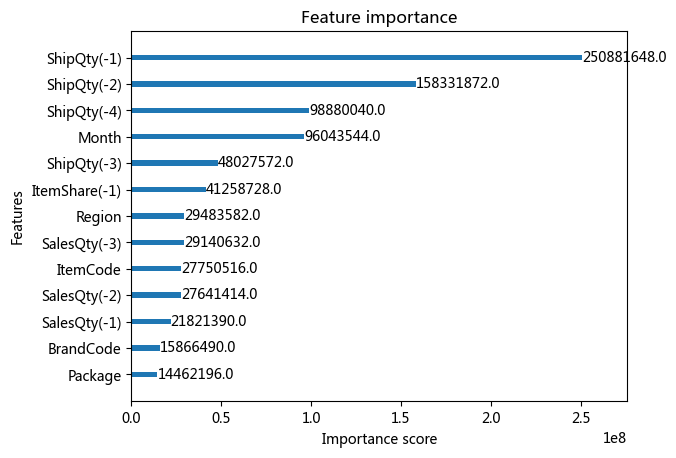

In [45]:
from xgboost import XGBClassifier, plot_importance
import matplotlib.pyplot as plt

plot_importance(model, importance_type='gain')
plt.grid(False)
plt.show()

## XGBoost 调参与优化 P96

In [46]:
import pandas as pd
import numpy as np
import itertools
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ========== 读取数据 ==========
df = pd.read_csv('./data/出货量预测/SalesShip.csv')
df["yearMonth"] = pd.to_datetime(df["yearMonth"], format="%Y-%m")

# ========== 特征准备 ==========
exclude_cols = ["SalesQty", "ItemShare", "ShipQty"]
feature_cols = [c for c in df.columns if c not in exclude_cols + ["yearMonth"]]

# 分类特征处理（XGBoost支持原生categorical）
cat_cols = ["Region", "ItemCode", "Package"]
for c in cat_cols:
    df[c] = df[c].astype("category")
    df[c] = df[c].cat.remove_unused_categories()

target_col = "ShipQty"
time_col = "yearMonth"

# ========== 划分训练集和最后一个月预测集 ==========
last_month = df[time_col].max()
train_df = df[df[time_col] < last_month]
test_df = df[df[time_col] == last_month]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"训练集: {train_df.shape}, 测试集（最后一个月）: {test_df.shape}")

# ========== 定义参数搜索空间 ==========
param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.02, 0.05],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "reg_alpha": [0, 0.3, 0.5],
    "reg_lambda": [1, 2],
}

param_combinations = list(itertools.product(*param_grid.values()))

print(f"共 {len(param_combinations)} 组参数待测试...")

# ========== 定义FA指标函数 ==========
def fa_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true > 0
    if np.any(mask):
        fa = 1 - np.sum(np.abs(y_pred[mask] - y_true[mask])) / np.sum(y_true[mask])
        return float(np.clip(fa, -1, 1))
    else:
        return np.nan

# ========== 遍历参数组合进行调参 ==========
results = []
best_fa = -np.inf
best_params = None
best_model = None

for combo in param_combinations:
    params = dict(zip(param_grid.keys(), combo))
    model = XGBRegressor(
        random_state=42,
        tree_method="hist",
        enable_categorical=True,
        n_estimators=500,
        early_stopping_rounds=50,
        **params
    )
    
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    fa = fa_score(y_test, pred)
    mask = y_test > 0
    mape = np.mean(np.abs((y_test[mask] - pred[mask]) / y_test[mask])) * 100 if np.any(mask) else np.nan

    results.append({
        **params,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape,
        "FA": fa
    })

    if fa > best_fa:
        best_fa = fa
        best_params = params
        best_model = model

# ========== 输出最优参数 ==========
print("\n===== 最优参数组合 =====")
print(best_params)
print(f"最佳FA: {best_fa:.4f}")

# ========== 重新预测并评估 ==========
pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, pred_best)
r2_best = r2_score(y_test, pred_best)
mask = y_test > 0
if np.any(mask):
    mape_best = np.mean(np.abs((y_test[mask] - pred_best[mask]) / y_test[mask])) * 100
    FA_best = 1 - np.sum(np.abs(pred_best[mask] - y_test[mask])) / np.sum(y_test[mask])
else:
    mape_best = np.nan
    FA_best = np.nan

print("\n===== 最终模型评估（最后一个月）=====")
print(f"MAE:  {mae_best:.2f}")
print(f"R²:   {r2_best:.4f}")
print(f"MAPE（ShipQty > 0）: {mape_best:.2f}%")
print(f"FA（预测准确率）: {FA_best:.4f}")

# ========== 10. 输出预测结果 ==========
pred_result = test_df.copy().reset_index(drop=True)
pred_result["Pred_ShipQty"] = pred_best
pred_result["Actual_ShipQty"] = y_test.values

# 保存结果
# pd.DataFrame(results).to_csv("xgb_param_search_results.csv", index=False)
# pred_result.to_csv("xgb_final_prediction.csv", index=False)

# print("\n参数搜索结果已保存到: xgb_param_search_results.csv")
# print("最终预测结果已保存到: xgb_final_prediction.csv")


训练集: (967, 17), 测试集（最后一个月）: (31, 17)
共 216 组参数待测试...

===== 最优参数组合 =====
{'max_depth': 5, 'learning_rate': 0.02, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1}
最佳FA: 0.8201

===== 最终模型评估（最后一个月）=====
MAE:  707.19
R²:   0.8654
MAPE（ShipQty > 0）: 27.38%
FA（预测准确率）: 0.8201


# 模型调优与评估深入

## 算法的选择 （回归）P100

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor

# 数据读取与预处理
data = pd.read_csv("./data/titanic/train.csv").dropna(subset=['Age'])
X = pd.get_dummies(data[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']])
y = data['Age']

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 投票回归模型
model = VotingRegressor([
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor(random_state=42))
]).fit(X_train, y_train)

# 预测与评估
y_pred = model.predict(X_test)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


RMSE: 11.1686


## 算法的选择 （分类）P100

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

# 读取与预处理数据
data = pd.read_csv("./data/titanic/train.csv").dropna(subset=['Survived', 'Embarked', 'Sex'])
X = pd.get_dummies(data[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']])
y = data['Survived']

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 投票分类器
model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42))
    ],
    voting='soft'  # soft 根据概率加权平均
).fit(X_train, y_train)

# 预测与评估
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"准确率: {accuracy_score(y_test, y_pred):.4f}")
print(f"精确率: {precision_score(y_test, y_pred):.4f}")
print(f"召回率: {recall_score(y_test, y_pred):.4f}")
print(f"F1值:  {f1_score(y_test, y_pred):.4f}")
print(f"AUC:  {roc_auc_score(y_test, y_prob):.4f}")


准确率: 0.7809
精确率: 0.7273
召回率: 0.6957
F1值:  0.7111
AUC:  0.8567


## 交叉验证的方法 P101

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# 读取并预处理数据
data = pd.read_csv("./data/titanic/train.csv").dropna(subset=['Survived', 'Embarked', 'Sex'])
X = pd.get_dummies(data[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']])
y = data['Survived'].values  # 转为 numpy 数组方便索引
X = X.values

# 5 折交叉验证，
# shuffle=True 划分数据前，先随机打乱
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    scores.append(accuracy_score(y_test, y_pred))

print(f"各折准确率: {np.round(scores, 4)}")
print(f"平均准确率: {np.mean(scores):.4f}")


各折准确率: [0.764  0.7865 0.8652 0.7865 0.7853]
平均准确率: 0.7975


## 交叉验证的方法 P102

In [50]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# 读取并预处理数据
data = pd.read_csv("./data/titanic/train.csv").dropna(subset=['Survived', 'Embarked', 'Sex'])
X = pd.get_dummies(data[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']])
y = data['Survived']

# 定义模型
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 5 折交叉验证
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("每折准确率:", scores)
print(f"平均准确率: {scores.mean():.4f}")


每折准确率: [0.7247191  0.76404494 0.83146067 0.80337079 0.83050847]
平均准确率: 0.7908


In [51]:
import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier

# 读取与预处理数据
data = pd.read_csv("./data/titanic/train.csv").dropna(subset=['Survived', 'Embarked', 'Sex'])
X = pd.get_dummies(data[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']])
y = data['Survived']

# 定义 K 折与模型
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 交叉验证
scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("每折准确率:", scores)
print(f"平均准确率: {scores.mean():.4f}")


每折准确率: [0.76404494 0.78651685 0.86516854 0.78651685 0.78531073]
平均准确率: 0.7975


## 交叉验证的方法: 时间序列 P102

In [52]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

X = np.arange(10)
tscv = TimeSeriesSplit(n_splits=3, test_size=2)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    print(f"Fold {fold}:")
    print("  训练集索引:", train_idx)
    print("  测试集索引:", test_idx)

Fold 1:
  训练集索引: [0 1 2 3]
  测试集索引: [4 5]
Fold 2:
  训练集索引: [0 1 2 3 4 5]
  测试集索引: [6 7]
Fold 3:
  训练集索引: [0 1 2 3 4 5 6 7]
  测试集索引: [8 9]


## 特征的选择：包裹法 P103

In [53]:
# 前向特征选择示例

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector

# 读取与预处理数据
data = pd.read_csv("./data/titanic/train.csv").dropna(subset=['Survived', 'Embarked', 'Sex'])
X = pd.get_dummies(data[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']])
y = data['Survived']

# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 定义模型
model = RandomForestClassifier(n_estimators=100, random_state=42)

# ---------- 前向特征选择 ----------
sfs_forward = SequentialFeatureSelector(
    model,
    n_features_to_select=4,   # 选择前4个最优特征
    direction='forward',      # 前向选择
    scoring='accuracy',       # 以准确率为评估指标
    cv=5                      # 5折交叉验证
)

# 拟合
sfs_forward.fit(X_train, y_train)

# 输出结果
selected_features = list(X.columns[sfs_forward.get_support()])
print("选择的特征：", selected_features)


选择的特征： ['Pclass', 'Fare', 'Sex_female', 'Embarked_Q']


In [54]:
# 后向剔除特征选择
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector

# 读取与预处理数据
data = pd.read_csv("./data/titanic/train.csv").dropna(subset=['Survived', 'Embarked', 'Sex'])
X = pd.get_dummies(data[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']])
y = data['Survived']

# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 定义模型
model = RandomForestClassifier(n_estimators=100, random_state=42)

# ---------- 后向特征剔除（Backward Elimination） ----------
sfs_backward = SequentialFeatureSelector(
    model,
    n_features_to_select=4,   # 最终保留 4 个特征
    direction='backward',     # 从所有特征开始逐步剔除
    scoring='accuracy',       # 以准确率为评估指标
    cv=5                      # 5 折交叉验证
)

# 拟合选择器
sfs_backward.fit(X_train, y_train)

# 输出选择结果
selected_features = list(X.columns[sfs_backward.get_support()])
print("选择的特征：", selected_features)


选择的特征： ['Pclass', 'Fare', 'Sex_male', 'Embarked_Q']


## 特征的选择： RFECV（递归特征消除） P104

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV

# 读取与预处理数据
data = pd.read_csv("./data/titanic/train.csv").dropna(subset=['Survived', 'Embarked', 'Sex'])
X = pd.get_dummies(data[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']])
y = data['Survived']

# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 定义模型
model = RandomForestClassifier(n_estimators=100, random_state=42)

# ---------- RFECV（递归特征消除 + 交叉验证） ----------
rfecv = RFECV(
    estimator=model,
    step=1,             # 每次剔除一个特征
    cv=5,               # 5 折交叉验证
    scoring='accuracy', # 以准确率为评价标准
    n_jobs=-1           # 并行加速（利用所有CPU核）
)

# 拟合模型
rfecv.fit(X_train, y_train)

# 输出结果
print("最优特征数量：", rfecv.n_features_)
print("被选择的特征：", list(X.columns[rfecv.support_]))


最优特征数量： 4
被选择的特征： ['Pclass', 'Fare', 'Sex_female', 'Sex_male']


## 参数调优：GridSearch、RandomSearch P105

In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 读取与预处理数据
data = pd.read_csv("./data/titanic/train.csv").dropna(subset=['Survived', 'Embarked', 'Sex'])
X = pd.get_dummies(data[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']])
y = data['Survived']

# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------- 网格搜索 ----------
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1          # 并行运行以加速搜索
)

# 执行搜索
grid_search.fit(X_train, y_train)

# 输出结果
print("最佳参数：", grid_search.best_params_)
print(f"最佳得分：{grid_search.best_score_:.4f}")


最佳参数： {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
最佳得分：0.8200


In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# 读取与预处理数据
data = pd.read_csv("./data/titanic/train.csv").dropna(subset=['Survived', 'Embarked', 'Sex'])
X = pd.get_dummies(data[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']])
y = data['Survived']

# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------- 随机搜索 ----------
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 10)
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,            # 随机采样 20 组参数
    scoring='accuracy',
    cv=5,                 # 5 折交叉验证
    random_state=42,
    n_jobs=-1             # 并行加速
)

# 拟合搜索
random_search.fit(X_train, y_train)

# 输出结果
print("最佳参数：", random_search.best_params_)
print(f"最佳得分：{random_search.best_score_:.4f}")


最佳参数： {'max_depth': 6, 'min_samples_split': 9, 'n_estimators': 376}
最佳得分：0.8270


## 正则化的方法：决策树 P111

In [58]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(
    max_depth=3,                     # 树最大深度
    min_samples_split=10,  # 分裂前节点最少样本数
    min_samples_leaf=5,     # 叶节点最少样本数
    max_leaf_nodes=8,         # 最大叶节点数
    random_state=42
)

## 正则化的方法：随机森林 P111

In [59]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,             # 树的数量
    max_depth=10,                   # 最大深度，防止树太深
    max_features='sqrt',         # 每次分裂使用部分特征
    min_samples_split=10,   # 节点继续划分所需的最小样本数
    min_samples_leaf=5,       # 叶节点的最小样本数
    bootstrap=True,                  # 有放回采样，增加随机性
    random_state=42              # 固定随机种子，保证结果可复现
) 


## 正则化的方法：XGBoost

In [60]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,             # 树的数量，越多越容易过拟合
    max_depth=5,                      # 每棵树的最大深度，控制模型复杂度
    learning_rate=0.1,               # 学习率（步长），越小越稳但需要更多树
    subsample=0.8,                    # 训练样本采样比例，防止模型过拟合
    colsample_bytree=0.8,      # 每棵树特征采样比例，增加随机性降低方差
    gamma=0.1,                 # 分裂惩罚项（最小损失减少量），越大越保守
    early_stopping_rounds=50,  # 验证集性能多轮未提升时提前停止训练
    eval_metric='logloss'      # 评估指标，可根据任务调整，如 'auc'、'rmse' 
)

# 模型可解释性

## 特征重要性：树模型 P117

In [61]:
# 模拟的供应链数据集

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
n_samples = 200

data = pd.DataFrame({
    "供应商等级": np.random.choice([1, 2, 3], size=n_samples, p=[0.3, 0.5, 0.2]),  # 供应商等级
    "节假日": np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3]),             # 是否节假日
    "天气": np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2]),               # 是否恶劣天气
    "仓库编码": np.random.choice([101, 102, 103], size=n_samples),                # 仓库编码
})

# 人为设定规则来生成目标变量（是否准时交付：1=准时, 0=延迟）
# 供应商等级越高、非节假日、好天气 → 更可能准时
data["准时交付"] = (
    (data["供应商等级"] == 3).astype(int) * 0.5
    + (1 - data["节假日"]) * 0.3
    + (1 - data["天气"]) * 0.15
    + np.random.rand(n_samples) * 0.2
)
data["准时交付"] = (data["准时交付"] > 0.5).astype(int)

# One-hot 编码类别型特征
X = pd.get_dummies(data.drop("准时交付", axis=1), drop_first=True)
y = data["准时交付"]

# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 决策树模型
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_importances = pd.Series(dt.feature_importances_, index=X.columns)


# 预测准确率
dt_acc = accuracy_score(y_test, dt.predict(X_test))

dt_importances = pd.Series(dt.feature_importances_, index=X.columns)
top4 = dt_importances.sort_values(ascending=False).head(4).round(3)
display(top4.to_frame(name='importance'))


,importance
供应商等级,0.380
天气,0.296
节假日,0.294
仓库编码,0.031


## 特征重要性：基于置换的重要性 P118

In [62]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

# 读取数据
data = pd.read_csv("./data/delivery_data.csv")

# 特征与目标
X = data.drop("是否准时", axis=1)
y = data["是否准时"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 训练模型
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 原始准确率
base_score = dt.score(X_test, y_test)

# 基于置换的重要性
result = permutation_importance(
    dt, X_test, y_test, n_repeats=10, random_state=42, scoring="accuracy"
)

display(pd.DataFrame({
    "feature": X.columns, "importance_mean": result.importances_mean, "importance_std": result.importances_std
}).sort_values(by="importance_mean", ascending=False))

# 整理结果表
importance_df = pd.DataFrame({
    "特征": X.columns,
    "打乱后准确率": base_score - result.importances_mean,
    "性能下降": result.importances_mean * -1,  # 降低的越多越重要
})

# 添加“重要性等级”
bins = [-float("inf"), -0.15, -0.05, -0.01, float("inf")]
labels = ["很高", "中等", "较低", "很低"]
importance_df["重要性"] = pd.cut(importance_df["性能下降"], bins=bins, labels=labels[::-1])

# 排序
importance_df = importance_df.sort_values(by="性能下降")

# 美化显示
styled_df = (
    importance_df.style
    .background_gradient(subset=["性能下降"], cmap="Blues", low=0.3, high=0)

)
display(styled_df)


,feature,importance_mean,importance_std
0,交付距离,0.087778,0.051508
3,天气情况,0.024444,0.031348
1,客户等级,0.013333,0.023201
2,发货时间,-0.035556,0.023201


,特征,打乱后准确率,性能下降,重要性
0,交付距离,0.623333,-0.087778,较低
3,天气情况,0.686667,-0.024444,中等
1,客户等级,0.697778,-0.013333,中等
2,发货时间,0.746667,0.035556,很高


## 物流发货的特征重要性：SHAP P119

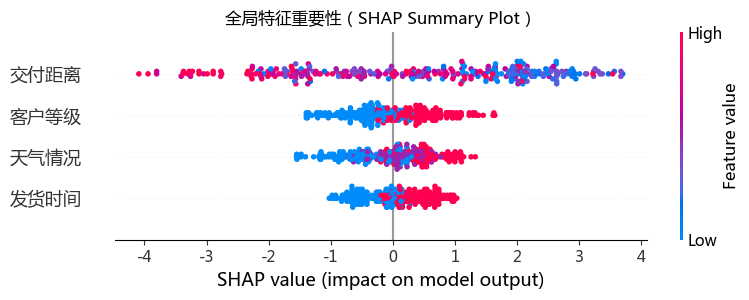

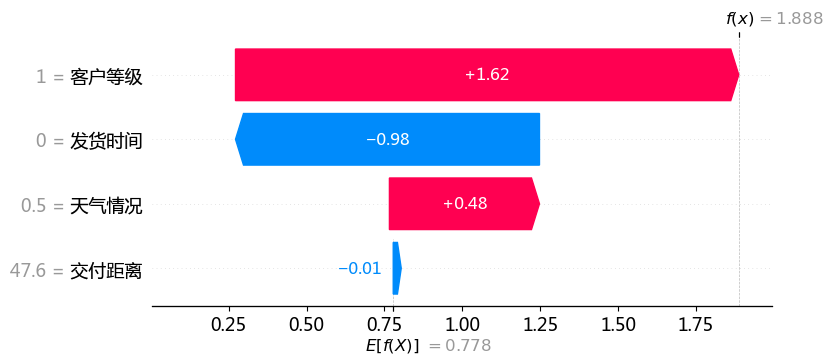

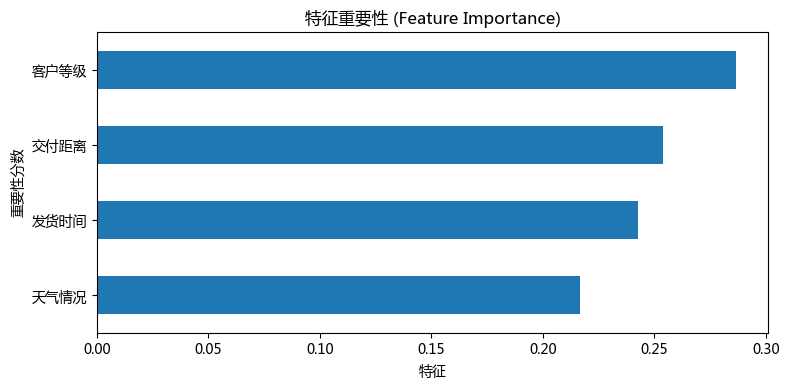

In [63]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

data_encoded = pd.read_csv("./data/delivery_data.csv")

# 准备特征与标签
X = data_encoded.drop(columns=["是否准时"])
y = data_encoded["是否准时"]

# 训练模型
model = xgb.XGBClassifier(eval_metric="logloss")
model.fit(X, y)

# 计算 SHAP 值
explainer = shap.Explainer(model)
shap_values = explainer(X)

# 绘制全局特征重要性
plt.title("全局特征重要性（SHAP Summary Plot）")
shap.summary_plot(shap_values, X, show=False)
plt.show()

# 绘制单样本解释
sample_index = 1
shap.plots.waterfall(shap_values[sample_index], max_display=10)

# 计算特征重要性并排序
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

# 画条形图
feature_importance.plot(kind='barh', figsize=(8, 4))
plt.title("特征重要性 (Feature Importance)")
plt.ylabel("重要性分数")
plt.xlabel("特征")
plt.tight_layout()
plt.show()

# 异常检测

## 物流异常检测：平均速度与偏离度 P125

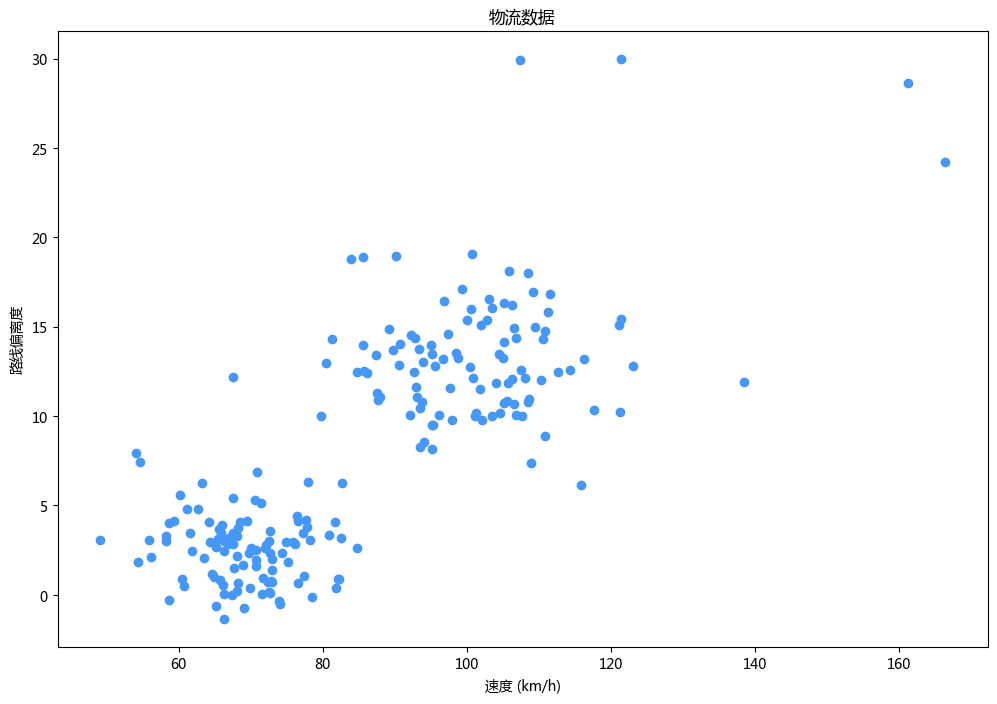

In [64]:
import numpy as np
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd

# === 数据生成 ===
np.random.seed(42)

# Cluster A: 城市运输（中心速度 70, 偏离度 2.5）
speed_A = np.random.normal(70, 8, 100)        # 均值70，标准差8 -> 更发散
deviation_A = np.random.normal(2.5, 2, 100)   # 均值2.5，标准差2
cluster_A = np.column_stack((speed_A, deviation_A))

# Cluster B: 高速运输（中心速度 100, 偏离度 12.5）
speed_B = np.random.normal(100, 10, 100)      # 均值100，标准差10
deviation_B = np.random.normal(12.5, 3, 100)  # 均值12.5，标准差3
cluster_B = np.column_stack((speed_B, deviation_B))

# Cluster B: 加入少量的异常的点
anom_speed_B = np.random.uniform(80, 180, 5)
anom_deviation_B = np.random.uniform(5, 30, 5)  
anom_points_B = np.column_stack((anom_speed_B, anom_deviation_B))
cluster_B = np.vstack((cluster_B, anom_points_B))

# === 可视化 ===
plt.figure(figsize=(12, 8))
plt.scatter(cluster_A[:, 0], cluster_A[:, 1], c="#4597F8", alpha=1)
plt.scatter(cluster_B[:, 0], cluster_B[:, 1], c="#4597F8", alpha=1)
plt.xlabel("速度 (km/h)")
plt.ylabel("路线偏离度")
plt.title("物流数据")
plt.show()


## 使用One-Class SVM进行异常检测 P126

In [65]:
# === 合并数据集 ===
X_train = np.vstack((cluster_A, cluster_B))

# === 训练 One-Class SVM 模型（平滑边界） ===
model = OneClassSVM(kernel='rbf', gamma=0.005, nu=0.08)
model.fit(X_train)

# === 预测与统计 ===
y_pred = model.predict(X_train)

print("预测结果统计（1=正常，-1=异常）:")
result_counts = pd.Series(y_pred).value_counts().sort_index()
print(result_counts)    

预测结果统计（1=正常，-1=异常）:
-1     16
 1    189
Name: count, dtype: int64


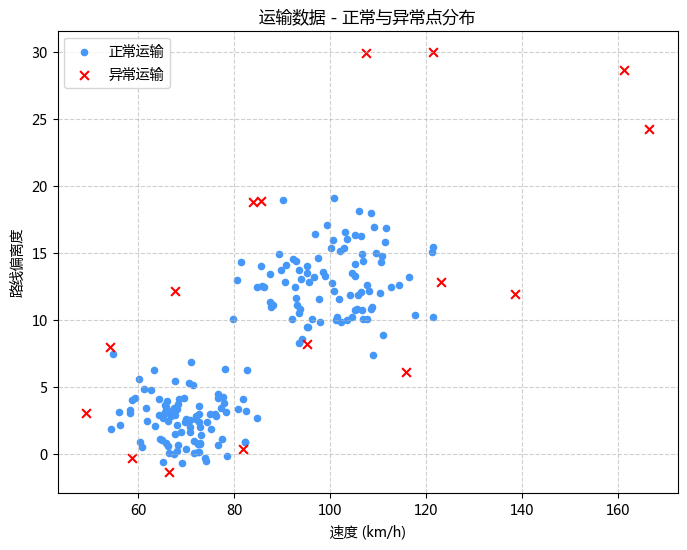

In [66]:
# 散点图绘制正常与异常点
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_pred == 1, 0], X_train[y_pred == 1, 1], c='#4597F8', s=20, label='正常运输')
plt.scatter(X_train[y_pred == -1, 0], X_train[y_pred == -1, 1], c='red', s=40, marker='x', label='异常运输')
plt.xlabel("速度 (km/h)")
plt.ylabel("路线偏离度")
plt.title("运输数据 - 正常与异常点分布")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 绘制决策边界图 P127

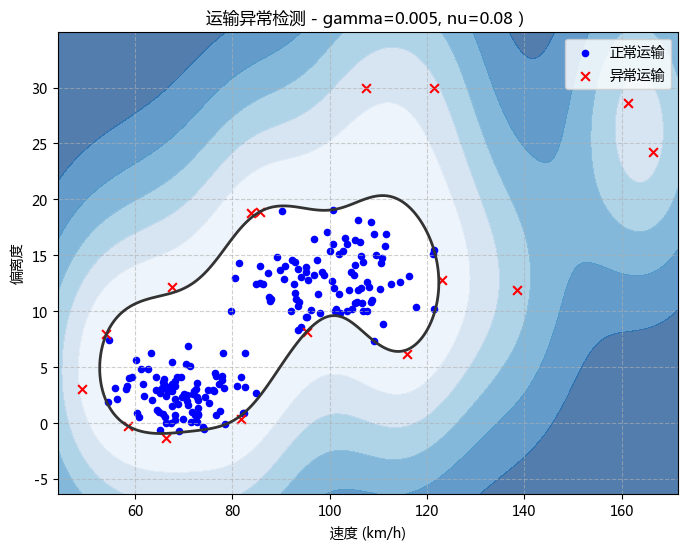

In [67]:

# 修改这儿的 gamma、nu 参数，观察决策边界变化

# === 训练 One-Class SVM 模型（平滑边界） ===
model = OneClassSVM(kernel='rbf', gamma=0.005, nu=0.08)
model.fit(X_train)

# === 预测与统计 ===
y_pred = model.predict(X_train)


# === 绘制决策边界图 ===
xx, yy = np.meshgrid(
    np.linspace(X_train[:, 0].min() - 5, X_train[:, 0].max() + 5, 300),
    np.linspace(X_train[:, 1].min() - 5, X_train[:, 1].max() + 5, 300)
)
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.title(f"运输异常检测 - gamma={model.gamma}, nu={model.nu}）")
plt.xlabel("速度 (km/h)")
plt.ylabel("偏离度")

# 背景：浅蓝色为正常区域
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7),
             cmap=plt.cm.Blues_r, alpha=0.7)

# 决策边界
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='#333333')

# 样本点
plt.scatter(X_train[y_pred == 1, 0], X_train[y_pred == 1, 1],
            c='blue', s=20, label='正常运输')
plt.scatter(X_train[y_pred == -1, 0], X_train[y_pred == -1, 1],
            c='red', s=40, marker='x', label='异常运输')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 使用One-Class SVM进行异常检测 P128

,决策分数
0,0.218380
1,0.254347
2,-0.139546
3,-1.691884


array([ 1,  1,  1, -1])

,速度 (km/h),路线偏离度,预测结果
0,60,2,正常
1,90,10,正常
2,120,20,正常
3,150,30,异常


测试数据预测结果（1=正常，-1=异常）:
速度: 60 km/h, 路线偏离度: 2, 预测: 正常
速度: 90 km/h, 路线偏离度: 10, 预测: 正常
速度: 120 km/h, 路线偏离度: 20, 预测: 正常
速度: 150 km/h, 路线偏离度: 30, 预测: 异常


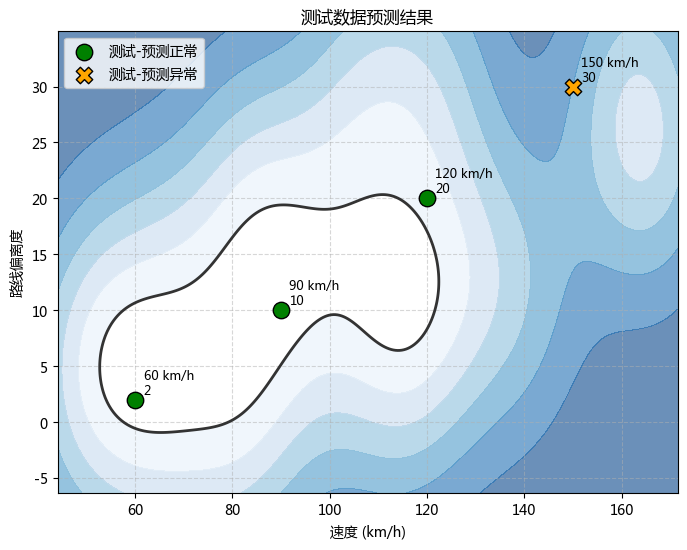

In [68]:

# === 测试数据 ===
test_speed = np.array([60, 90, 120, 150]) 
test_deviation = np.array([2, 10, 20, 30]) 
X_test = np.column_stack((test_speed, test_deviation))

# display_df = pd.DataFrame(X_test, columns=['速度 (km/h)', '路线偏离度'])
# display(display_df)

# 应用模型进行预测
# y_test_pred = model.predict(X_test)


# 使用样本点到决策边界的距离，来决定是否异常
scores = model.decision_function(X_test)
display(pd.DataFrame(scores, columns=['决策分数']   ))
y_test_pred = np.where(scores >= -0.2, 1, -1)
display(y_test_pred)

# 用 pandas 合并测试数据和预测结果，并用 display 显示
test_result_df = pd.DataFrame({
    "速度 (km/h)": test_speed,
    "路线偏离度": test_deviation,
    "预测结果": ["正常" if p == 1 else "异常" for p in y_test_pred]
})
display(test_result_df)


print("测试数据预测结果（1=正常，-1=异常）:")
for s, d, pred in zip(test_speed, test_deviation, y_test_pred):
    print(f"速度: {s} km/h, 路线偏离度: {d}, 预测: {'正常' if pred == 1 else '异常'}")

# 在决策边界上绘制并标注测试点的预测结果
plt.figure(figsize=(8, 6))

# 背景：决策分数（使用已计算的 xx, yy, Z）
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.Blues_r, alpha=0.6)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='#333333')

# 测试样本：按预测结果着色并放大显示
plt.scatter(X_test[y_test_pred == 1, 0], X_test[y_test_pred == 1, 1],
            c='green', s=140, edgecolors='k', label='测试-预测正常', zorder=5)
plt.scatter(X_test[y_test_pred == -1, 0], X_test[y_test_pred == -1, 1],
            c='orange', s=140, marker='X', edgecolors='k', label='测试-预测异常', zorder=5)

# 标注每个测试点（速度 / 偏离度）
for s, d, pred in zip(test_speed, test_deviation, y_test_pred):
    plt.annotate(f"{int(s)} km/h\n{int(d)}", (s, d), textcoords="offset points", xytext=(6, 4), fontsize=9)

plt.xlabel("速度 (km/h)")
plt.ylabel("路线偏离度")
plt.title("测试数据预测结果")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show() 



## 使用Isolation Forest进行异常检测 P129

预测结果统计（1=正常，-1=异常）:
-1     17
 1    188
Name: count, dtype: int64


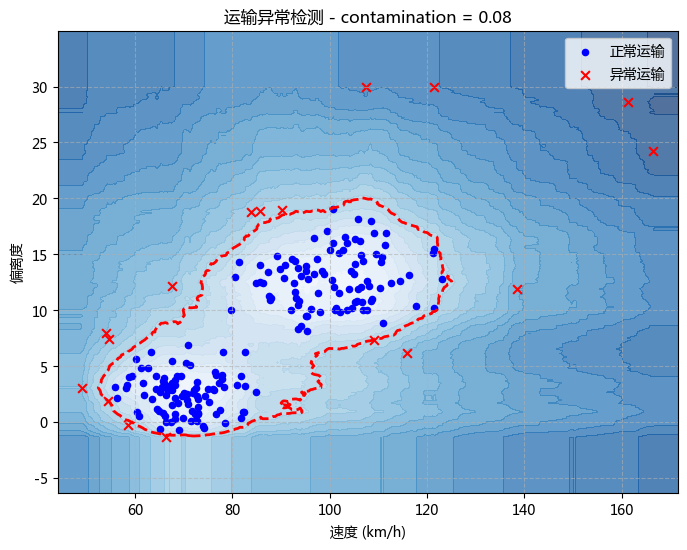

In [69]:
# 重新运行 Isolation Forest 决策边界绘制代码

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from matplotlib import rcParams

# === 训练 Isolation Forest 模型 ===
model = IsolationForest(
    n_estimators=200,
    contamination=0.08,
    random_state=42
)
model.fit(X_train)

# === 预测与统计 ===
y_pred = model.predict(X_train)

print("预测结果统计（1=正常，-1=异常）:")
result_counts = pd.Series(y_pred).value_counts().sort_index()
print(result_counts)

# === 绘制决策边界图 ===
xx, yy = np.meshgrid(
    np.linspace(X_train[:, 0].min() - 5, X_train[:, 0].max() + 5, 300),
    np.linspace(X_train[:, 1].min() - 5, X_train[:, 1].max() + 5, 300)
)
Z = model.score_samples(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.title(f"运输异常检测 - contamination = {model.contamination}")
plt.xlabel("速度 (km/h)")
plt.ylabel("偏离度")

# 蓝色背景
plt.contourf(xx, yy, Z, levels=20, cmap=plt.cm.Blues_r, alpha=0.7)

# 红色边界线
threshold = np.percentile(model.score_samples(X_train), 100 * 0.08)
plt.contour(xx, yy, Z, levels=[threshold], linewidths=2, colors='red')

# 样本点
plt.scatter(X_train[y_pred == 1, 0], X_train[y_pred == 1, 1],
            c='blue', s=20, label='正常运输')
plt.scatter(X_train[y_pred == -1, 0], X_train[y_pred == -1, 1],
            c='red', s=40, marker='x', label='异常运输')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# 机器学习中的 AI 辅助

## AutoGluon 应用举例（回归） P137

In [70]:
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.model_selection import train_test_split
import pandas as pd

titanic = pd.read_csv('./data/titanic.csv')
titanic = titanic[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]

titanic = titanic.dropna(subset=['Age']) # 删除 Age 缺失值
label = 'Age' # 设置目标变量为 Age

train_data, test_data = train_test_split(titanic, test_size=0.2, random_state=42)

# 训练模型（回归任务）
predictor = TabularPredictor(
    label=label,
    eval_metric='root_mean_squared_error',  # RMSE
    verbosity=0  # 不输出过程日志
).fit(train_data, presets='medium_quality') # medium_quality 一般质量

# 输出模型评估结果
performance = predictor.evaluate(test_data)
# print(performance)

# 转为 DataFrame
metrics_df = pd.DataFrame(performance.items(), columns=["指标", "数值"])

# 保留两位小数并美化显示
styled = (
    metrics_df.style
    .format({"数值": "{:.4f}"})
)
display(styled)

,指标,数值
0,root_mean_squared_error,-11.6549
1,mean_squared_error,-135.8368
2,mean_absolute_error,-9.0249
3,r2,0.2673
4,pearsonr,0.5375
5,median_absolute_error,-7.4857


## AutoGluon 应用举例（分类） P138

In [71]:
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.model_selection import train_test_split
import pandas as pd

titanic = pd.read_csv('./data/titanic.csv')
titanic = titanic[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]

train_data, test_data = train_test_split(titanic, test_size=0.2,
           random_state=42, stratify=titanic['Survived']  # 保持类别比例
)
label = 'Survived'

# 训练模型
predictor = TabularPredictor(
    label=label,
    eval_metric='accuracy', # 准确率
    verbosity=0 # 不输出过程日志
).fit(train_data, presets='medium_quality') # medium_quality 一般质量

# 输出模型评估结果：
performance = predictor.evaluate(test_data)
# print(performance)


# 转为 DataFrame
metrics_df = pd.DataFrame(performance.items(), columns=["指标", "数值"])

# 保留两位小数并美化显示
styled = (
    metrics_df.style
    .format({"数值": "{:.4f}"})
)
display(styled)

,指标,数值
0,accuracy,0.8101
1,balanced_accuracy,0.7779
2,mcc,0.5926
3,roc_auc,0.8177
4,f1,0.7213
5,precision,0.8302
6,recall,0.6377


In [72]:
# 输出分类的结果
preds = predictor.predict(test_data.drop(columns=[label]))
print(preds.head(3))

565    0
160    0
553    0
Name: Survived, dtype: int64


In [73]:
# 输出分类的结果概率
preds = predictor.predict_proba(test_data.drop(columns=[label]))
print(preds.head(3))

            0         1
565  0.767477  0.232523
160  0.624235  0.375765
553  0.692017  0.307983


## AutoGluon 查看模型列表与特征重要性 P138

In [74]:
leaderboard = predictor.leaderboard(silent=True)
# 模型名称，验证集分数，训练时长，预测时长
display(leaderboard[['model', 'score_val', 'fit_time', 'pred_time_val']])

info = predictor.info() # 查看超参数信息
display(info['model_info']['XGBoost']['hyperparameters'])

importance = predictor.feature_importance(test_data)
print(importance)

,model,score_val,fit_time,pred_time_val
0,LightGBMLarge,0.874126,2.728430,0.000955
1,WeightedEnsemble_L2,0.874126,2.750258,0.001213
2,LightGBM,0.860140,0.620395,0.001054
3,XGBoost,0.860140,0.278300,0.001664
4,NeuralNetFastAI,0.860140,0.218981,0.003345
5,CatBoost,0.853147,0.278195,0.000759
6,NeuralNetTorch,0.846154,0.604813,0.003074
7,LightGBMXT,0.839161,0.409309,0.000948
8,RandomForestEntr,0.832168,0.179777,0.012003
9,RandomForestGini,0.825175,0.218652,0.013481


{'n_estimators': 10000,
 'learning_rate': 0.1,
 'n_jobs': -1,
 'proc.max_category_levels': 100,
 'objective': 'binary:logistic',
 'booster': 'gbtree'}

          importance    stddev   p_value  n  p99_high   p99_low
Sex         0.174302  0.027197  0.000069  5  0.230301  0.118303
Pclass      0.105028  0.013338  0.000031  5  0.132491  0.077565
Age         0.045810  0.024796  0.007240  5  0.096865 -0.005245
Fare        0.043575  0.016478  0.002048  5  0.077504  0.009647
SibSp       0.015642  0.010746  0.015615  5  0.037769 -0.006484
Parch       0.015642  0.012739  0.025803  5  0.041873 -0.010588
Embarked    0.007821  0.008472  0.053969  5  0.025266 -0.009624


## AutoGluon 报告输出

In [75]:
predictor.fit_summary(show_plot=True)

*** Summary of fit() ***
Estimated performance of each model:
                  model  score_val eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0         LightGBMLarge   0.874126    accuracy       0.000955  2.728430                0.000955           2.728430            1       True         11
1   WeightedEnsemble_L2   0.874126    accuracy       0.001213  2.750258                0.000258           0.021828            2       True         12
2              LightGBM   0.860140    accuracy       0.001054  0.620395                0.001054           0.620395            1       True          2
3               XGBoost   0.860140    accuracy       0.001664  0.278300                0.001664           0.278300            1       True          9
4       NeuralNetFastAI   0.860140    accuracy       0.003345  0.218981                0.003345           0.218981            1       True          8
5              CatBoost   0.853147    

{'model_types': {'LightGBMXT': 'LGBModel',
  'LightGBM': 'LGBModel',
  'RandomForestGini': 'RFModel',
  'RandomForestEntr': 'RFModel',
  'CatBoost': 'CatBoostModel',
  'ExtraTreesGini': 'XTModel',
  'ExtraTreesEntr': 'XTModel',
  'NeuralNetFastAI': 'NNFastAiTabularModel',
  'XGBoost': 'XGBoostModel',
  'NeuralNetTorch': 'TabularNeuralNetTorchModel',
  'LightGBMLarge': 'LGBModel',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBMXT': 0.8391608391608392,
  'LightGBM': 0.8601398601398601,
  'RandomForestGini': 0.8251748251748252,
  'RandomForestEntr': 0.8321678321678322,
  'CatBoost': 0.8531468531468531,
  'ExtraTreesGini': 0.8181818181818182,
  'ExtraTreesEntr': 0.8111888111888111,
  'NeuralNetFastAI': 0.8601398601398601,
  'XGBoost': 0.8601398601398601,
  'NeuralNetTorch': 0.8461538461538461,
  'LightGBMLarge': 0.8741258741258742,
  'WeightedEnsemble_L2': 0.8741258741258742},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'LightGBMXT': ['LightGB